In [1]:
import os.path as op
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
td_color=np.array([27,158,119])/255.0
asd_color=np.array([117,112,179])/255.0

In [5]:
all_bursts = {
    'subject_id': [],
    'group': [],
    'epoch_type': [],
    'condition': [],
    'cluster': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0, 156)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

all_beta_power={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])

In [6]:
burst_idx = (all_bursts['group']=='TD') & (all_bursts['cluster']=='contra')

In [7]:
for key in all_bursts.keys():
    if key=='waveform_times':
        continue
    elif key=='waveform':
        all_bursts[key] = all_bursts[key][burst_idx,:]
    else:
        all_bursts[key] = all_bursts[key][burst_idx]

In [8]:
stim_idx = all_bursts['epoch_type']=='STIM'
resp_idx = all_bursts['epoch_type']=='RESP'

In [9]:
waveform_times=all_bursts['waveform_times']

In [10]:
n=len(np.unique(all_bursts['subject_id']))
print(f'N subjects={n}')

subject_ids=np.unique(all_bursts['subject_id'])

N subjects=33


In [11]:
# bin_width = 0.025
# stim_time_bins = np.arange(-1.75, 1.75, bin_width)
# resp_time_bins = np.arange(-1.75, 1.75, bin_width)

# short_color = 'r'
# long_color = 'b'

# stim_plt_idx = (stim_time_bins[:-1] >= -1.5) & (stim_time_bins[:-1] <= .5)
# resp_plt_idx = (resp_time_bins[:-1] >= -.5) & (resp_time_bins[:-1] <= 1.5)
# stim_time_plt = stim_time_bins[:-1][stim_plt_idx]
# resp_time_plt = resp_time_bins[:-1][resp_plt_idx]
# base_idx = np.where((stim_time_bins >= -1.5) & (stim_time_bins < -1.25))[0]

# overall_rates = {
#     epoch_type: {condition: [] for condition in condition_names}
#     for epoch_type in epoch_types
# }

# for subject_id in subject_ids:
#     for condition in condition_names:
#         b_stim = (
#             (all_bursts['subject_id'] == subject_id) &
#             (all_bursts['epoch_type'] == 'STIM') &
#             (all_bursts['condition'] == condition)
#         )
#         b_resp = (
#             (all_bursts['subject_id'] == subject_id) &
#             (all_bursts['epoch_type'] == 'RESP') &
#             (all_bursts['condition'] == condition)
#         )
#         stim_trials = np.unique(all_bursts['trial'][b_stim])
#         resp_trials = np.unique(all_bursts['trial'][b_resp])
#         if len(stim_trials) == 0 or len(resp_trials) == 0:
#             continue

#         stim_rate, _ = np.histogram(all_bursts['peak_time'][b_stim], bins=stim_time_bins)
#         stim_rate = gaussian_filter1d((stim_rate / bin_width) / len(stim_trials), sigma=2.5, mode='nearest')

#         resp_rate, _ = np.histogram(all_bursts['peak_time'][b_resp], bins=resp_time_bins)
#         resp_rate = gaussian_filter1d((resp_rate / bin_width) / len(resp_trials), sigma=2.5, mode='nearest')

#         # baseline from STIM epoch, applied to both
#         base_rate = np.mean(stim_rate[base_idx])
#         overall_rates['STIM'][condition].append(((stim_rate - base_rate) / base_rate * 100)[stim_plt_idx])
#         overall_rates['RESP'][condition].append(((resp_rate - base_rate) / base_rate * 100)[resp_plt_idx])

# for epoch_type in epoch_types:
#     for condition in condition_names:
#         overall_rates[epoch_type][condition] = np.array(overall_rates[epoch_type][condition])

# threshold_tfce = dict(start=0, step=0.01)

# fig, axes_list = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# for ax, (epoch_type, time_plt) in zip(axes_list, zip(epoch_types, [stim_time_plt, resp_time_plt])):
#     for condition, color in zip(condition_names, [short_color, long_color]):
#         data = overall_rates[epoch_type][condition]
#         m = np.mean(data, axis=0)
#         se = np.std(data, axis=0) / np.sqrt(data.shape[0])
#         ax.plot(time_plt, m, color=color, label=condition)
#         ax.fill_between(time_plt, m - se, m + se, color=color, alpha=0.25)

#     data = [overall_rates[epoch_type]['SHORT'], overall_rates[epoch_type]['LONG']]
#     T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
#         data, stat_fun=paired_t, threshold=threshold_tfce, n_permutations=1000, tail=0
#     )
#     print_cluster_results(T_obs, clusters, cluster_p_values, None, time_plt,
#                           f"Burst rate - {epoch_type}: SHORT vs LONG")

#     yl = ax.get_ylim()
#     py = yl[1] + .1 * (yl[1] - 0)
#     for p_idx, p_val in enumerate(cluster_p_values):
#         if p_val < 0.05:
#             ax.plot(time_plt[p_idx], py, 'k*')

#     ax.axvline(0, color='k', linestyle='--')
#     ax.set_title(epoch_type)
#     ax.set_xlabel('Time (s)')

# axes_list[0].set_ylabel('Δ burst rate (%)')
# axes_list[0].legend()

# plt.tight_layout()
# plt.show()

In [12]:
from scipy.ndimage import label as ndlabel

def print_cluster_results(T_obs, clusters, cluster_p_values, freqs, times, label):
    print(f"\n{'='*50}")
    print(f"Cluster results: {label}")
    print(f"{'='*50}")

    sig_mask = np.zeros(T_obs.shape, dtype=bool)
    for clu, p in zip(clusters, cluster_p_values):
        if p < 0.05:
            sig_mask[clu] = True

    if not sig_mask.any():
        print("No significant clusters (p < .05)")
        return

    labeled, n_regions = ndlabel(sig_mask)
    print(f"  {n_regions} contiguous significant region(s) found\n")

    for region_idx in range(1, n_regions + 1):
        region_mask = labeled == region_idx
        indices = np.where(region_mask)
        t_vals = T_obs[region_mask]
        region_ps = [p for clu, p in zip(clusters, cluster_p_values)
                     if p < 0.05 and region_mask[clu].any()]

        print(f"  Region #{region_idx}:")
        print(f"    p range: [{min(region_ps):.4f}, {max(region_ps):.4f}]")
        print(f"    T range: [{t_vals.min():.3f}, {t_vals.max():.3f}]")

        if T_obs.ndim == 2:
            freq_idx, time_idx = indices
            print(f"    Frequency: {freqs[freq_idx.min()]:.1f} - {freqs[freq_idx.max()]:.1f} Hz")
            print(f"    Time: {times[time_idx.min()]:.3f} - {times[time_idx.max()]:.3f} s")
        else:
            time_idx = indices[0]
            print(f"    Time: {times[time_idx.min()]:.3f} - {times[time_idx.max()]:.3f} s")

        print(f"    Size (pixels): {region_mask.sum()}")

Median age: 14.6 | N low: 17 | N high: 16
stat_fun(H1): min=-1.501031 max=2.551696
Running initial clustering …
Using 256 thresholds from 0.00 to 2.55 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate - STIM SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-1.666316 max=1.791828
Running initial clustering …
Using 180 thresholds from 0.00 to 1.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate - STIM LONG: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-0.978128 max=1.970103
Running initial clustering …
Using 198 thresholds from 0.00 to 1.97 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate - RESP SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.073364 max=2.370623
Running initial clustering …
Using 238 thresholds from 0.00 to 2.37 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate - RESP LONG: high vs low age
No significant clusters (p < .05)


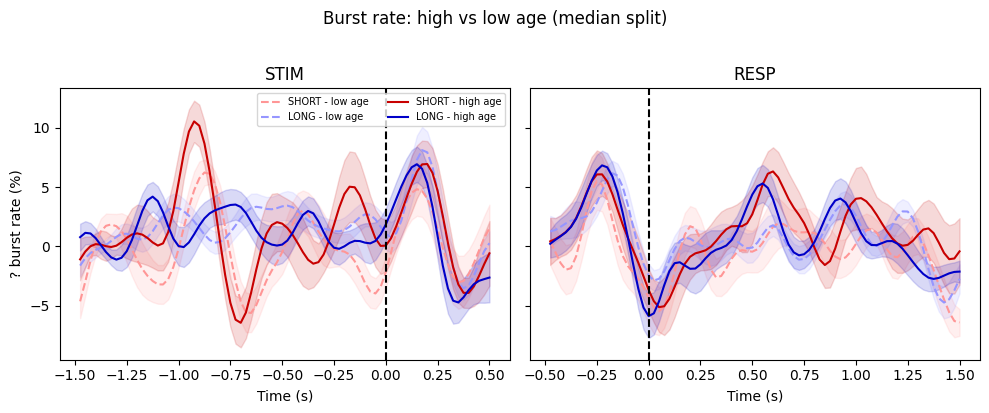

In [13]:
bin_width = 0.025
stim_time_bins = np.arange(-1.75, 1.75, bin_width)
resp_time_bins = np.arange(-1.75, 1.75, bin_width)
stim_plt_idx = (stim_time_bins[:-1] >= -1.5) & (stim_time_bins[:-1] <= .5)
resp_plt_idx = (resp_time_bins[:-1] >= -.5)  & (resp_time_bins[:-1] <= 1.5)
stim_time_plt = stim_time_bins[:-1][stim_plt_idx]
resp_time_plt = resp_time_bins[:-1][resp_plt_idx]
base_idx = np.where((stim_time_bins >= -1.5) & (stim_time_bins < -1.25))[0]

overall_rates   = {ep: {c: [] for c in condition_names} for ep in epoch_types}
valid_subject_ids = []  # track subjects that actually made it in

for subject_id in subject_ids:
    rates_this_subj = {}
    skip = False
    for condition in condition_names:
        b_stim = (
            (all_bursts['subject_id'] == subject_id) &
            (all_bursts['epoch_type'] == 'STIM') &
            (all_bursts['condition'] == condition)
        )
        b_resp = (
            (all_bursts['subject_id'] == subject_id) &
            (all_bursts['epoch_type'] == 'RESP') &
            (all_bursts['condition'] == condition)
        )
        stim_trials = np.unique(all_bursts['trial'][b_stim])
        resp_trials = np.unique(all_bursts['trial'][b_resp])
        if len(stim_trials) == 0 or len(resp_trials) == 0:
            skip = True
            break
        stim_rate, _ = np.histogram(all_bursts['peak_time'][b_stim], bins=stim_time_bins)
        stim_rate = gaussian_filter1d((stim_rate / bin_width) / len(stim_trials), sigma=2.5, mode='nearest')
        resp_rate, _ = np.histogram(all_bursts['peak_time'][b_resp], bins=resp_time_bins)
        resp_rate = gaussian_filter1d((resp_rate / bin_width) / len(resp_trials), sigma=2.5, mode='nearest')
        base_rate = np.mean(stim_rate[base_idx])
        rates_this_subj[condition] = {
            'STIM': ((stim_rate - base_rate) / base_rate * 100)[stim_plt_idx],
            'RESP': ((resp_rate - base_rate) / base_rate * 100)[resp_plt_idx],
        }
    if skip:
        continue
    valid_subject_ids.append(subject_id)
    for condition in condition_names:
        overall_rates['STIM'][condition].append(rates_this_subj[condition]['STIM'])
        overall_rates['RESP'][condition].append(rates_this_subj[condition]['RESP'])

for epoch_type in epoch_types:
    for condition in condition_names:
        overall_rates[epoch_type][condition] = np.array(overall_rates[epoch_type][condition])

# --- age median split aligned to valid_subject_ids ---
age_lookup = {}
for csv_file in [
    op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'),
    op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv')
]:
    demo = pd.read_csv(csv_file)
    for _, row in demo.iterrows():
        age_lookup[row['ParticipantID']] = row['AgeAtImaging']

subject_ages = np.array([age_lookup[s] for s in valid_subject_ids])
median_age   = np.median(subject_ages)
low_idx      = np.where(subject_ages <= median_age)[0]
high_idx     = np.where(subject_ages >  median_age)[0]
print(f'Median age: {median_age:.1f} | N low: {len(low_idx)} | N high: {len(high_idx)}')

age_colors = {
    'low':  {'SHORT': np.array([255, 150, 150]) / 255,
             'LONG':  np.array([150, 150, 255]) / 255},
    'high': {'SHORT': np.array([200,   0,   0]) / 255,
             'LONG':  np.array([  0,   0, 200]) / 255},
}

def ttest_ind_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_ind(x, y, axis=axis, nan_policy='omit')
    return tvals

ind_t = partial(ttest_ind_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.01)

fig, axes_list = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, (epoch_type, time_plt) in zip(axes_list, zip(epoch_types, [stim_time_plt, resp_time_plt])):
    for age_label, idx in [('low', low_idx), ('high', high_idx)]:
        for condition in condition_names:
            data_sub = overall_rates[epoch_type][condition][idx]
            m   = np.mean(data_sub, axis=0)
            se  = np.std(data_sub,  axis=0) / np.sqrt(len(idx))
            col = age_colors[age_label][condition]
            ls  = '--' if age_label == 'low' else '-'
            ax.plot(time_plt, m, color=col, linestyle=ls,
                    label=f'{condition} - {age_label} age')
            ax.fill_between(time_plt, m - se, m + se, color=col, alpha=0.15)

    for condition, offset in zip(condition_names, [0.08, 0.16]):
        data = [
            overall_rates[epoch_type][condition][high_idx],
            overall_rates[epoch_type][condition][low_idx],
        ]
        T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
            data, stat_fun=ind_t, threshold=threshold_tfce, n_permutations=1000, tail=0
        )
        print_cluster_results(T_obs, clusters, cluster_p_values, None, time_plt,
                              f"Burst rate - {epoch_type} {condition}: high vs low age")
        yl  = ax.get_ylim()
        py  = yl[1] + offset * (yl[1] - yl[0])
        col = age_colors['high'][condition]
        for clu, p_val in zip(clusters, cluster_p_values):
            if p_val < 0.05:
                ax.plot(time_plt[clu[0]], np.full(len(clu[0]), py), color=col, linewidth=3)

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(epoch_type)
    ax.set_xlabel('Time (s)')

axes_list[0].set_ylabel('? burst rate (%)')
axes_list[0].legend(fontsize=7, ncol=2)
plt.suptitle('Burst rate: high vs low age (median split)', y=1.02)
plt.tight_layout()
plt.show()

N bursts: 1139914 | top 10% per subject: 114005
Burst rate around unexpected and expected go cues - all bursts | N subjects: 33 | 33rd pct: 12.9 | 67th pct: 15.6
youngest: n=11 | middle: n=11 | oldest: n=11
stat_fun(H1): min=-5.158624 max=3.972870
Running initial clustering …
Using 516 thresholds from 0.00 to 5.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate around unexpected and expected go cues - all bursts - STIM: SHORT vs LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0150, 0.0370]
    T range: [0.036, 0.040]
    Time: -0.900 - -0.850 s
    Size (pixels): 3
  Region #2:
    p range: [0.0020, 0.0060]
    T range: [-0.052, -0.044]
    Time: -0.725 - -0.650 s
    Size (pixels): 4
stat_fun(H1): min=-2.349150 max=1.592188
Running initial clustering …
Using 235 thresholds from 0.00 to 2.34 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate around unexpected and expected go cues - all bursts - RESP: SHORT vs LONG
No significant clusters (p < .05)
stat_fun(H1): min=-2.434287 max=1.998896
Running initial clustering …
Using 244 thresholds from 0.00 to 2.43 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: Burst rate around unexpected and expected go cues - all bursts - RESP LONG: youngest vs middle
No significant clusters (p < .05)
stat_fun(H1): min=-2.524309 max=0.957050
Running initial clustering …
Using 253 thresholds from 0.00 to 2.52 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate around unexpected and expected go cues - all bursts - RESP LONG: middle vs oldest
No significant clusters (p < .05)
stat_fun(H1): min=-2.700785 max=1.809543
Running initial clustering …
Using 271 thresholds from 0.00 to 2.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate around unexpected and expected go cues - all bursts - RESP LONG: youngest vs oldest
No significant clusters (p < .05)


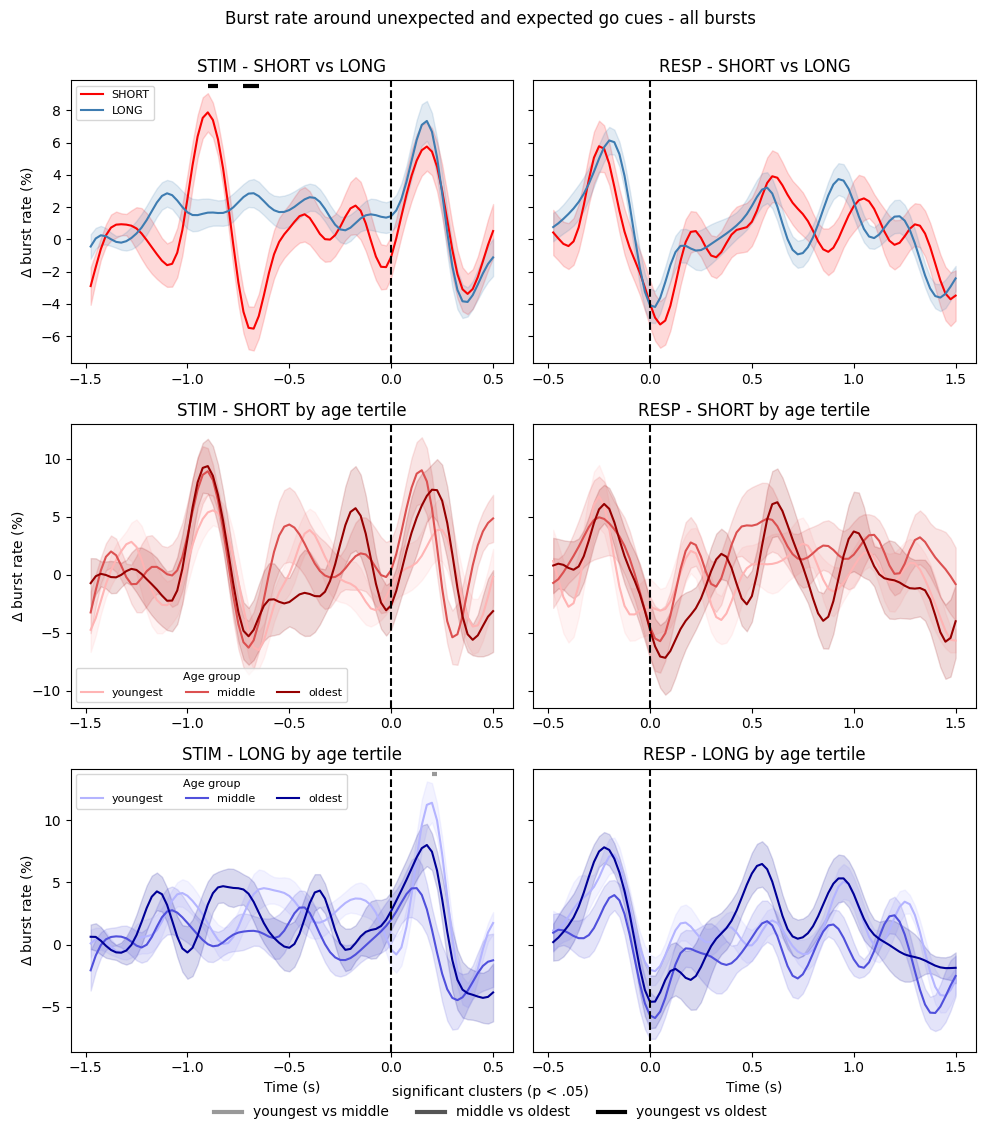

In [18]:
from matplotlib.transforms import blended_transform_factory
from scipy.stats import ttest_rel

short_color = "#F90202"
long_color  = '#3E7CB1'

age_names   = {'low': 'youngest', 'mid': 'middle', 'high': 'oldest'}
age_shades  = {
    'SHORT': {'low': np.array([255, 180, 180]) / 255,
              'mid': np.array([220,  80,  80]) / 255,
              'high': np.array([150,   0,   0]) / 255},
    'LONG':  {'low': np.array([180, 180, 255]) / 255,
              'mid': np.array([ 80,  80, 220]) / 255,
              'high': np.array([  0,   0, 150]) / 255},
}
comparisons = [('low', 'mid', '#999999', 0.98),
               ('mid', 'high', '#555555', 0.94),
               ('low', 'high', '#000000', 0.90)]

def plot_sig(ax, times, clusters, cluster_p_values, y_frac, color):
    mask = np.zeros(len(times), dtype=bool)
    for clu, p_val in zip(clusters, cluster_p_values):
        if p_val < 0.05:
            mask[clu[0]] = True
    if not mask.any():
        return
    t_sig = np.asarray(times, dtype=float).copy()
    t_sig[~mask] = np.nan
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.plot(t_sig, np.full(len(t_sig), y_frac), transform=trans,
            color=color, linewidth=3, solid_capstyle='butt', clip_on=False)

# --- burst rates for a given burst subset ---
def compute_rates(burst_mask):
    rates = {ep: {c: [] for c in condition_names} for ep in epoch_types}
    valid_ids = []

    for subject_id in subject_ids:
        rates_this_subj = {}
        skip = False
        for condition in condition_names:
            in_cell = ((all_bursts['subject_id'] == subject_id) &
                       (all_bursts['condition'] == condition))
            b_stim = in_cell & (all_bursts['epoch_type'] == 'STIM') & burst_mask
            b_resp = in_cell & (all_bursts['epoch_type'] == 'RESP') & burst_mask

            stim_trials = np.unique(all_bursts['trial'][in_cell & (all_bursts['epoch_type'] == 'STIM')])
            resp_trials = np.unique(all_bursts['trial'][in_cell & (all_bursts['epoch_type'] == 'RESP')])
            if len(stim_trials) == 0 or len(resp_trials) == 0:
                skip = True
                break

            stim_rate, _ = np.histogram(all_bursts['peak_time'][b_stim], bins=stim_time_bins)
            stim_rate = gaussian_filter1d((stim_rate / bin_width) / len(stim_trials), sigma=2.5, mode='nearest')
            resp_rate, _ = np.histogram(all_bursts['peak_time'][b_resp], bins=resp_time_bins)
            resp_rate = gaussian_filter1d((resp_rate / bin_width) / len(resp_trials), sigma=2.5, mode='nearest')

            base_rate = np.mean(stim_rate[base_idx])
            if base_rate == 0:
                skip = True
                break

            rates_this_subj[condition] = {
                'STIM': ((stim_rate - base_rate) / base_rate * 100)[stim_plt_idx],
                'RESP': ((resp_rate - base_rate) / base_rate * 100)[resp_plt_idx],
            }
        if skip:
            continue
        valid_ids.append(subject_id)
        for condition in condition_names:
            for ep in epoch_types:
                rates[ep][condition].append(rates_this_subj[condition][ep])

    for ep in epoch_types:
        for c in condition_names:
            rates[ep][c] = np.array(rates[ep][c])
    return rates, valid_ids

def paired_t(x, y, axis=0):
    tvals, _ = ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals
# --- figure, same layout as the beta power panel ---
def make_figure(rates, valid_ids, suptitle, fname):
    ages = np.array([age_lookup[s] for s in valid_ids])
    t33, t67 = np.percentile(ages, 33.33), np.percentile(ages, 66.67)
    age_idx = {
        'low':  np.where(ages <= t33)[0],
        'mid':  np.where((ages > t33) & (ages <= t67))[0],
        'high': np.where(ages > t67)[0],
    }
    print(f'{suptitle} | N subjects: {len(valid_ids)} | 33rd pct: {t33:.1f} | 67th pct: {t67:.1f}')
    print(' | '.join(f'{age_names[k]}: n={len(v)}' for k, v in age_idx.items()))

    epoch_time_pairs = list(zip(epoch_types, [stim_time_plt, resp_time_plt]))
    fig, axes = plt.subplots(3, 2, figsize=(10, 11), sharey='row')

    # --- Row 0: SHORT vs LONG (paired) ---
    for col, (epoch_type, times) in enumerate(epoch_time_pairs):
        ax = axes[0, col]

        for condition, color in zip(condition_names, [short_color, long_color]):
            d  = rates[epoch_type][condition]
            m  = np.nanmean(d, axis=0)
            se = np.nanstd(d, axis=0) / np.sqrt(d.shape[0])
            ax.plot(times, m, color=color, label=condition)
            ax.fill_between(times, m - se, m + se, color=color, alpha=0.15)

        T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
            [rates[epoch_type]['SHORT'], rates[epoch_type]['LONG']],
            stat_fun=paired_t, threshold=threshold_tfce, n_permutations=1000, tail=0
        )
        print_cluster_results(T_obs, clusters, cluster_p_values, None, times,
                              f"{suptitle} - {epoch_type}: SHORT vs LONG")
        plot_sig(ax, times, clusters, cluster_p_values, 0.98, 'k')

        ax.axvline(0, color='k', linestyle='--')
        ax.set_title(f'{epoch_type} - SHORT vs LONG')
        if col == 0:
            ax.set_ylabel(r'$\Delta$ burst rate (%)')
            ax.legend(fontsize=8)

    # --- Rows 1-2: age tertiles, one condition per row ---
    for r, condition in enumerate(condition_names, start=1):
        for col, (epoch_type, times) in enumerate(epoch_time_pairs):
            ax = axes[r, col]

            for age_label in ['low', 'mid', 'high']:
                d  = rates[epoch_type][condition][age_idx[age_label]]
                m  = np.nanmean(d, axis=0)
                se = np.nanstd(d, axis=0) / np.sqrt(d.shape[0])
                ax.plot(times, m, color=age_shades[condition][age_label],
                        label=age_names[age_label])
                ax.fill_between(times, m - se, m + se,
                                color=age_shades[condition][age_label], alpha=0.15)

            for a, b, comp_color, y_frac in comparisons:
                data = [rates[epoch_type][condition][age_idx[a]],
                        rates[epoch_type][condition][age_idx[b]]]
                T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
                    data, stat_fun=ind_t, threshold=threshold_tfce, n_permutations=1000, tail=0
                )
                print_cluster_results(T_obs, clusters, cluster_p_values, None, times,
                                      f"{suptitle} - {epoch_type} {condition}: {age_names[a]} vs {age_names[b]}")
                plot_sig(ax, times, clusters, cluster_p_values, y_frac, comp_color)

            ax.axvline(0, color='k', linestyle='--')
            ax.set_title(f'{epoch_type} - {condition} by age tertile')
            if col == 0:
                ax.set_ylabel(r'$\Delta$ burst rate (%)')
                ax.legend(fontsize=8, ncol=3, title='Age group', title_fontsize=8)

    for ax in axes[2, :]:
        ax.set_xlabel('Time (s)')
    for ax in axes.ravel():
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))

    handles = [plt.Line2D([], [], color=c, linewidth=3,
                          label=f'{age_names[a]} vs {age_names[b]}')
               for a, b, c, _ in comparisons]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.02), title='significant clusters (p < .05)')

    fig.suptitle(suptitle, y=1.0)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# --- burst subsets ---
n_bursts = len(all_bursts['peak_amp_base'])

all_idx = np.ones(n_bursts, dtype=bool)

high_amp_idx = np.zeros(n_bursts, dtype=bool)
for subject_id in subject_ids:
    subj_mask = all_bursts['subject_id'] == subject_id
    thresh = np.percentile(all_bursts['peak_amp_base'][subj_mask], 90)
    high_amp_idx[subj_mask] = all_bursts['peak_amp_base'][subj_mask] >= thresh
print(f'N bursts: {n_bursts} | top 10% per subject: {high_amp_idx.sum()}')

rates_all, valid_all = compute_rates(all_idx)
make_figure(rates_all, valid_all,
            'Burst rate around unexpected and expected go cues - all bursts',
            'burst_rate_all_short_vs_long_and_age_tertiles.png')

Burst rate around unexpected and expected go cues - top 10% amplitude bursts | N subjects: 33 | 33rd pct: 12.9 | 67th pct: 15.6
youngest: n=11 | middle: n=11 | oldest: n=11
stat_fun(H1): min=-6.083835 max=3.372621
Running initial clustering …
Using 609 thresholds from 0.00 to 6.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate around unexpected and expected go cues - top 10% amplitude bursts - STIM: SHORT vs LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0480]
    T range: [-0.061, -0.033]
    Time: -0.725 - -0.500 s
    Size (pixels): 10
  Region #2:
    p range: [0.0430, 0.0480]
    T range: [0.033, 0.034]
    Time: 0.050 - 0.075 s
    Size (pixels): 2
stat_fun(H1): min=-0.191912 max=4.869377
Running initial clustering …
Using 487 thresholds from 0.00 to 4.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate around unexpected and expected go cues - top 10% amplitude bursts - RESP: SHORT vs LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0160, 0.0330]
    T range: [0.033, 0.037]
    Time: -0.375 - -0.275 s
    Size (pixels): 5
  Region #2:
    p range: [0.0010, 0.0420]
    T range: [0.032, 0.049]
    Time: 0.950 - 1.375 s
    Size (pixels): 18
stat_fun(H1): min=-1.975444 max=2.766974
Running initial clustering …
Using 277 thresholds from 0.00 to 2.76 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: Burst rate around unexpected and expected go cues - top 10% amplitude bursts - RESP LONG: youngest vs middle
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0070, 0.0380]
    T range: [0.034, 0.041]
    Time: -0.225 - -0.100 s
    Size (pixels): 6
  Region #2:
    p range: [0.0380, 0.0380]
    T range: [0.034, 0.034]
    Time: 0.050 - 0.075 s
    Size (pixels): 2
stat_fun(H1): min=-0.338621 max=2.276878
Running initial clustering …
Using 228 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate around unexpected and expected go cues - top 10% amplitude bursts - RESP LONG: middle vs oldest
No significant clusters (p < .05)
stat_fun(H1): min=-1.090400 max=4.428896
Running initial clustering …
Using 443 thresholds from 0.00 to 4.42 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: Burst rate around unexpected and expected go cues - top 10% amplitude bursts - RESP LONG: youngest vs oldest
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0420, 0.0490]
    T range: [0.035, 0.035]
    Time: -0.200 - -0.150 s
    Size (pixels): 3
  Region #2:
    p range: [0.0060, 0.0420]
    T range: [0.035, 0.044]
    Time: 0.050 - 0.175 s
    Size (pixels): 6


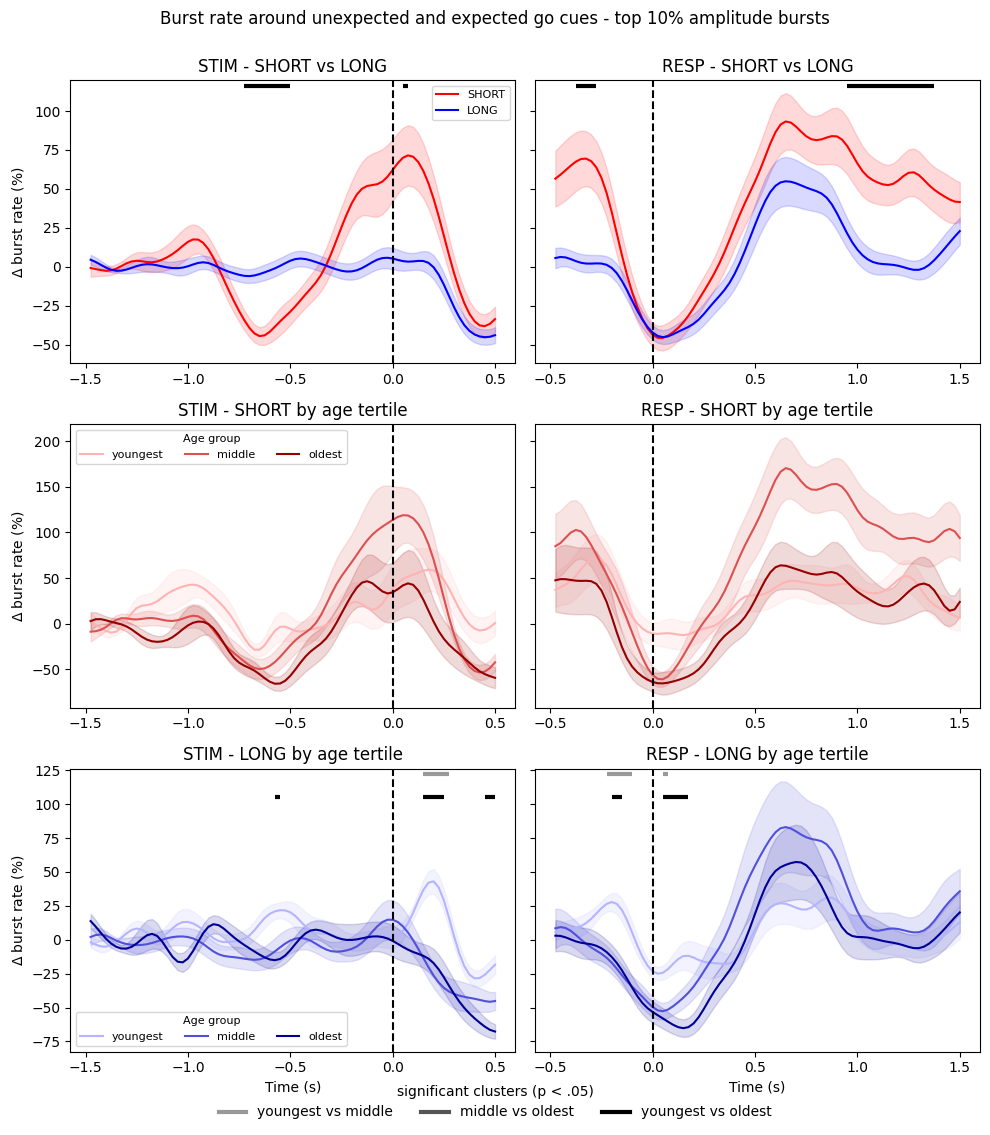

In [ ]:
rates_ha, valid_ha = compute_rates(high_amp_idx)
make_figure(rates_ha, valid_ha,
            'Burst rate around unexpected and expected go cues - top 10% amplitude bursts',
            'burst_rate_highamp_short_vs_long_and_age_tertiles.png')

Amplitude threshold: top 10% per subject | N bursts: 114005
N subjects with valid high-amp rates: 33
High-amp | 33rd pct: 12.9 | 67th pct: 15.6 | N low: 11 | N mid: 11 | N high: 11
stat_fun(H1): min=-6.083835 max=3.372621
Running initial clustering …
Using 609 thresholds from 0.00 to 6.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: High-amp burst rate - STIM: SHORT vs LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0460]
    T range: [-0.061, -0.033]
    Time: -0.725 - -0.500 s
    Size (pixels): 10
  Region #2:
    p range: [0.0390, 0.0460]
    T range: [0.033, 0.034]
    Time: 0.050 - 0.075 s
    Size (pixels): 2
stat_fun(H1): min=-0.191912 max=4.869377
Running initial clustering …
Using 487 thresholds from 0.00 to 4.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: High-amp burst rate - RESP: SHORT vs LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0100, 0.0380]
    T range: [0.033, 0.037]
    Time: -0.375 - -0.275 s
    Size (pixels): 5
  Region #2:
    p range: [0.0010, 0.0380]
    T range: [0.033, 0.049]
    Time: 0.975 - 1.375 s
    Size (pixels): 17
stat_fun(H1): min=-1.975444 max=2.766974
Running initial clustering …
Using 277 thresholds from 0.00 to 2.76 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: High-amp burst rate - RESP LONG: low vs mid
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0060, 0.0290]
    T range: [0.034, 0.041]
    Time: -0.225 - -0.100 s
    Size (pixels): 6
  Region #2:
    p range: [0.0280, 0.0470]
    T range: [0.032, 0.034]
    Time: 0.025 - 0.075 s
    Size (pixels): 3
stat_fun(H1): min=-0.338621 max=2.276878
Running initial clustering …
Using 228 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: High-amp burst rate - RESP LONG: mid vs high
No significant clusters (p < .05)
stat_fun(H1): min=-1.090400 max=4.428896
Running initial clustering …
Using 443 thresholds from 0.00 to 4.42 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: High-amp burst rate - RESP LONG: low vs high
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0390, 0.0460]
    T range: [0.034, 0.035]
    Time: -0.200 - -0.125 s
    Size (pixels): 4
  Region #2:
    p range: [0.0090, 0.0390]
    T range: [0.035, 0.044]
    Time: 0.050 - 0.175 s
    Size (pixels): 6


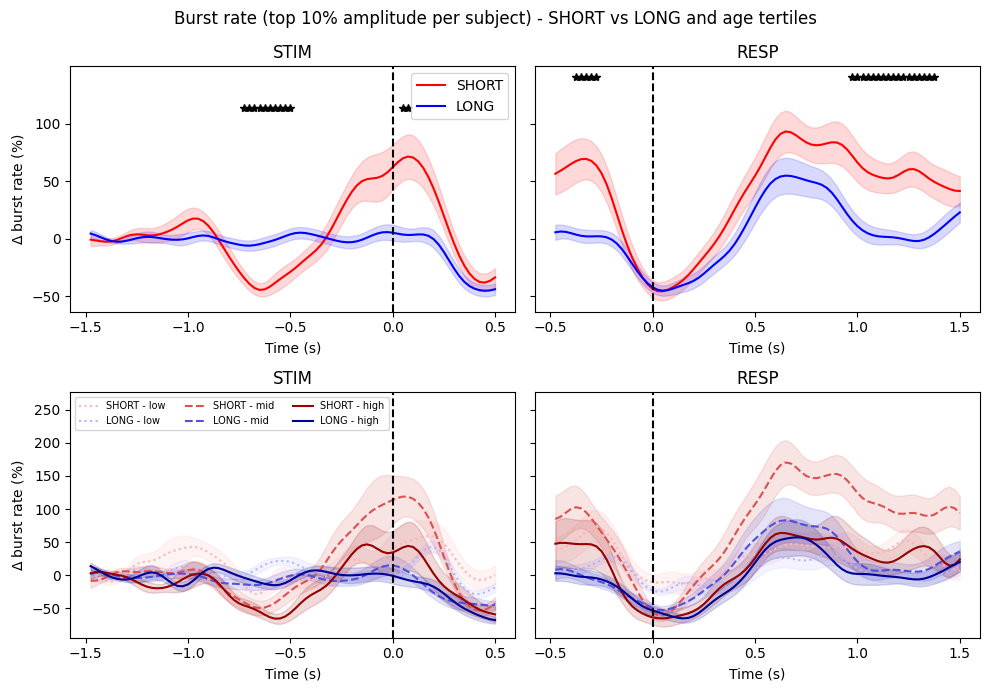

In [ ]:
n_bursts = len(all_bursts['peak_amp_base'])
high_amp_idx = np.zeros(n_bursts, dtype=bool)
for subject_id in subject_ids:
    subj_mask = all_bursts['subject_id'] == subject_id
    thresh = np.percentile(all_bursts['peak_amp_base'][subj_mask], 90)
    high_amp_idx[subj_mask] = all_bursts['peak_amp_base'][subj_mask] >= thresh
print(f'Amplitude threshold: top 10% per subject | N bursts: {high_amp_idx.sum()}')

overall_rates_highamp = {ep: {c: [] for c in condition_names} for ep in epoch_types}
valid_subject_ids_highamp = []

for subject_id in subject_ids:
    rates_this_subj = {}
    skip = False
    for condition in condition_names:
        b_stim = (
            (all_bursts['subject_id'] == subject_id) &
            (all_bursts['epoch_type'] == 'STIM') &
            (all_bursts['condition'] == condition) &
            high_amp_idx
        )
        b_resp = (
            (all_bursts['subject_id'] == subject_id) &
            (all_bursts['epoch_type'] == 'RESP') &
            (all_bursts['condition'] == condition) &
            high_amp_idx
        )
        stim_trials = np.unique(all_bursts['trial'][
            (all_bursts['subject_id'] == subject_id) &
            (all_bursts['epoch_type'] == 'STIM') &
            (all_bursts['condition'] == condition)
        ])
        resp_trials = np.unique(all_bursts['trial'][
            (all_bursts['subject_id'] == subject_id) &
            (all_bursts['epoch_type'] == 'RESP') &
            (all_bursts['condition'] == condition)
        ])
        if len(stim_trials) == 0 or len(resp_trials) == 0:
            skip = True
            break

        stim_rate, _ = np.histogram(all_bursts['peak_time'][b_stim], bins=stim_time_bins)
        stim_rate = gaussian_filter1d((stim_rate / bin_width) / len(stim_trials), sigma=2.5, mode='nearest')
        resp_rate, _ = np.histogram(all_bursts['peak_time'][b_resp], bins=resp_time_bins)
        resp_rate = gaussian_filter1d((resp_rate / bin_width) / len(resp_trials), sigma=2.5, mode='nearest')

        base_rate = np.mean(stim_rate[base_idx])
        if base_rate == 0:
            skip = True
            break

        rates_this_subj[condition] = {
            'STIM': ((stim_rate - base_rate) / base_rate * 100)[stim_plt_idx],
            'RESP': ((resp_rate - base_rate) / base_rate * 100)[resp_plt_idx],
        }
    if skip:
        continue
    valid_subject_ids_highamp.append(subject_id)
    for condition in condition_names:
        overall_rates_highamp['STIM'][condition].append(rates_this_subj[condition]['STIM'])
        overall_rates_highamp['RESP'][condition].append(rates_this_subj[condition]['RESP'])

for ep in epoch_types:
    for c in condition_names:
        overall_rates_highamp[ep][c] = np.array(overall_rates_highamp[ep][c])

print(f'N subjects with valid high-amp rates: {len(valid_subject_ids_highamp)}')

# --- age split (tertiles) ---
subject_ages_highamp = np.array([age_lookup[s] for s in valid_subject_ids_highamp])
t33_ha = np.percentile(subject_ages_highamp, 33.33)
t67_ha = np.percentile(subject_ages_highamp, 66.67)

low_idx_ha  = np.where(subject_ages_highamp <= t33_ha)[0]
mid_idx_ha  = np.where((subject_ages_highamp > t33_ha) & (subject_ages_highamp <= t67_ha))[0]
high_idx_ha = np.where(subject_ages_highamp > t67_ha)[0]

print(f'High-amp | 33rd pct: {t33_ha:.1f} | 67th pct: {t67_ha:.1f} | '
      f'N low: {len(low_idx_ha)} | N mid: {len(mid_idx_ha)} | N high: {len(high_idx_ha)}')

age_colors = {
    'low':  {'SHORT': np.array([255, 180, 180]) / 255,
             'LONG':  np.array([180, 180, 255]) / 255},
    'mid':  {'SHORT': np.array([220,  80,  80]) / 255,
             'LONG':  np.array([ 80,  80, 220]) / 255},
    'high': {'SHORT': np.array([150,   0,   0]) / 255,
             'LONG':  np.array([  0,   0, 150]) / 255},
}

FILL_ALPHA = 0.15

fig, axes_grid = plt.subplots(2, 2, figsize=(10, 7), sharey='row')
fig.suptitle('Burst rate (top 10% amplitude per subject) - SHORT vs LONG and age tertiles')

epoch_time_pairs = list(zip(epoch_types, [stim_time_plt, resp_time_plt]))

# --- Row 0: SHORT vs LONG (paired) ---
row0_axes = []
for col, (epoch_type, time_plt) in enumerate(epoch_time_pairs):
    ax = axes_grid[0, col]

    for condition, color in zip(condition_names, [short_color, long_color]):
        data = overall_rates_highamp[epoch_type][condition]
        m  = np.nanmean(data, axis=0)
        se = np.nanstd(data,  axis=0) / np.sqrt(data.shape[0])
        ax.plot(time_plt, m, color=color, label=condition)
        ax.fill_between(time_plt, m - se, m + se, color=color, alpha=FILL_ALPHA)

    T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
        [overall_rates_highamp[epoch_type]['SHORT'],
         overall_rates_highamp[epoch_type]['LONG']],
        stat_fun=paired_t, threshold=threshold_tfce, n_permutations=1000, tail=0
    )
    print_cluster_results(T_obs, clusters, cluster_p_values, None, time_plt,
                          f"High-amp burst rate - {epoch_type}: SHORT vs LONG")

    yl = ax.get_ylim()
    py = yl[1] + .1 * (yl[1] - yl[0])
    for p_idx, p_val in enumerate(cluster_p_values):
        if p_val < 0.05:
            ax.plot(time_plt[p_idx], py, 'k*')

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(epoch_type)
    ax.set_xlabel('Time (s)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    if col == 0:
        ax.set_ylabel(r'$\Delta$ burst rate (%)')
        ax.legend()
    row0_axes.append(ax)

# --- Row 1: age tertiles (independent), all pairwise comparisons ---
row1_axes = []
for col, (epoch_type, time_plt) in enumerate(epoch_time_pairs):
    ax = axes_grid[1, col]

    for age_label, idx in [('low', low_idx_ha), ('mid', mid_idx_ha), ('high', high_idx_ha)]:
        for condition in condition_names:
            data_sub = overall_rates_highamp[epoch_type][condition][idx]
            m    = np.nanmean(data_sub, axis=0)
            se   = np.nanstd(data_sub,  axis=0) / np.sqrt(len(idx))
            col_ = age_colors[age_label][condition]
            ls   = ':' if age_label == 'low' else ('--' if age_label == 'mid' else '-')
            ax.plot(time_plt, m, color=col_, linestyle=ls,
                    label=f'{condition} - {age_label}')
            ax.fill_between(time_plt, m - se, m + se, color=col_, alpha=FILL_ALPHA)

    comparisons = [
        ('low vs mid',  low_idx_ha,  mid_idx_ha,  0.02),
        ('mid vs high', mid_idx_ha,  high_idx_ha, 0.04),
        ('low vs high', low_idx_ha,  high_idx_ha, 0.06),
    ]
    for condition in condition_names:
        for comp_label, idx_a, idx_b, offset in comparisons:
            data = [
                overall_rates_highamp[epoch_type][condition][idx_a],
                overall_rates_highamp[epoch_type][condition][idx_b],
            ]
            T_obs, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
                data, stat_fun=ind_t, threshold=threshold_tfce, n_permutations=1000, tail=0
            )
            print_cluster_results(T_obs, clusters, cluster_p_values, None, time_plt,
                                  f"High-amp burst rate - {epoch_type} {condition}: {comp_label}")

            yl = ax.get_ylim()
            py = yl[1] + offset * (yl[1] - yl[0])
            sig_color = age_colors['high'][condition]
            for clu, p_val in zip(clusters, cluster_p_values):
                if p_val < 0.05:
                    ax.plot(time_plt[clu[0]], np.full(len(clu[0]), py),
                            color=sig_color, linewidth=3)

    ax.axvline(0, color='k', linestyle='--')
    ax.set_title(epoch_type)
    ax.set_xlabel('Time (s)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    if col == 0:
        ax.set_ylabel(r'$\Delta$ burst rate (%)')
        ax.legend(fontsize=7, ncol=3)
    row1_axes.append(ax)

for row_axes in [row0_axes, row1_axes]:
    ymins, ymaxs = zip(*[ax.get_ylim() for ax in row_axes])
    for ax in row_axes:
        ax.set_ylim(np.min(ymins), np.max(ymaxs))

plt.tight_layout()
plt.savefig('burst_rate_highamp_short_vs_long_and_age_tertiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def shuffle_array(array):
    X_array = array.copy()
    rows, columns = array.shape
    for col in range(columns):
        ixes = np.arange(0,rows)
        np.random.shuffle(ixes)
        X_array[:,col] = X_array[:,col][ixes]
    return X_array

def shuffle_array_range(array, ranges):
    X_array = []
    for x1, x2 in ranges:
        X = wvf[:,x1:x2]
        np.random.shuffle(X)
        X_array.append(X)
    return np.hstack(X_array)

def get_num_components(waveforms, n_comps):
    # robust scaling
#     waveforms_scaled = RobustScaler().fit_transform(waveforms)
    waveforms_scaled=np.zeros(waveforms.shape)
    for subject in np.unique(all_bursts['subject_id']):
        s_idx=all_bursts['subject_id']==subject
        waveforms_scaled[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
    waveforms_scaled = RobustScaler().fit_transform(waveforms_scaled)


    # main PCA fitting
    pca_full = PCA(n_components=n_comps)
    pcs_full = pca_full.fit_transform(waveforms_scaled)
    var_full = pca_full.explained_variance_ratio_ 

    # robustness of pca components
    no_of_iter = 100
    pca_vars = []
    for i in range(no_of_iter):
        shuffled_wvf = shuffle_array(waveforms_scaled)

        pca_shuff = PCA(n_components=n_comps)
        pca_shuff.fit(shuffled_wvf)
        pca_vars.append(pca_shuff.explained_variance_ratio_)        
    del shuffled_wvf
    pca_vars=np.array(pca_vars)

    # getting the magic number
    results = np.sum(var_full>pca_vars, axis=0) / no_of_iter
    threshold=1-(.05/n_comps)
    PCS_to_analyse = np.where(results > threshold)[0]
    return PCS_to_analyse

shuffling_results=get_num_components(all_bursts['waveform'], 20)
print(f'Non-noise PCs: {shuffling_results}')

Non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


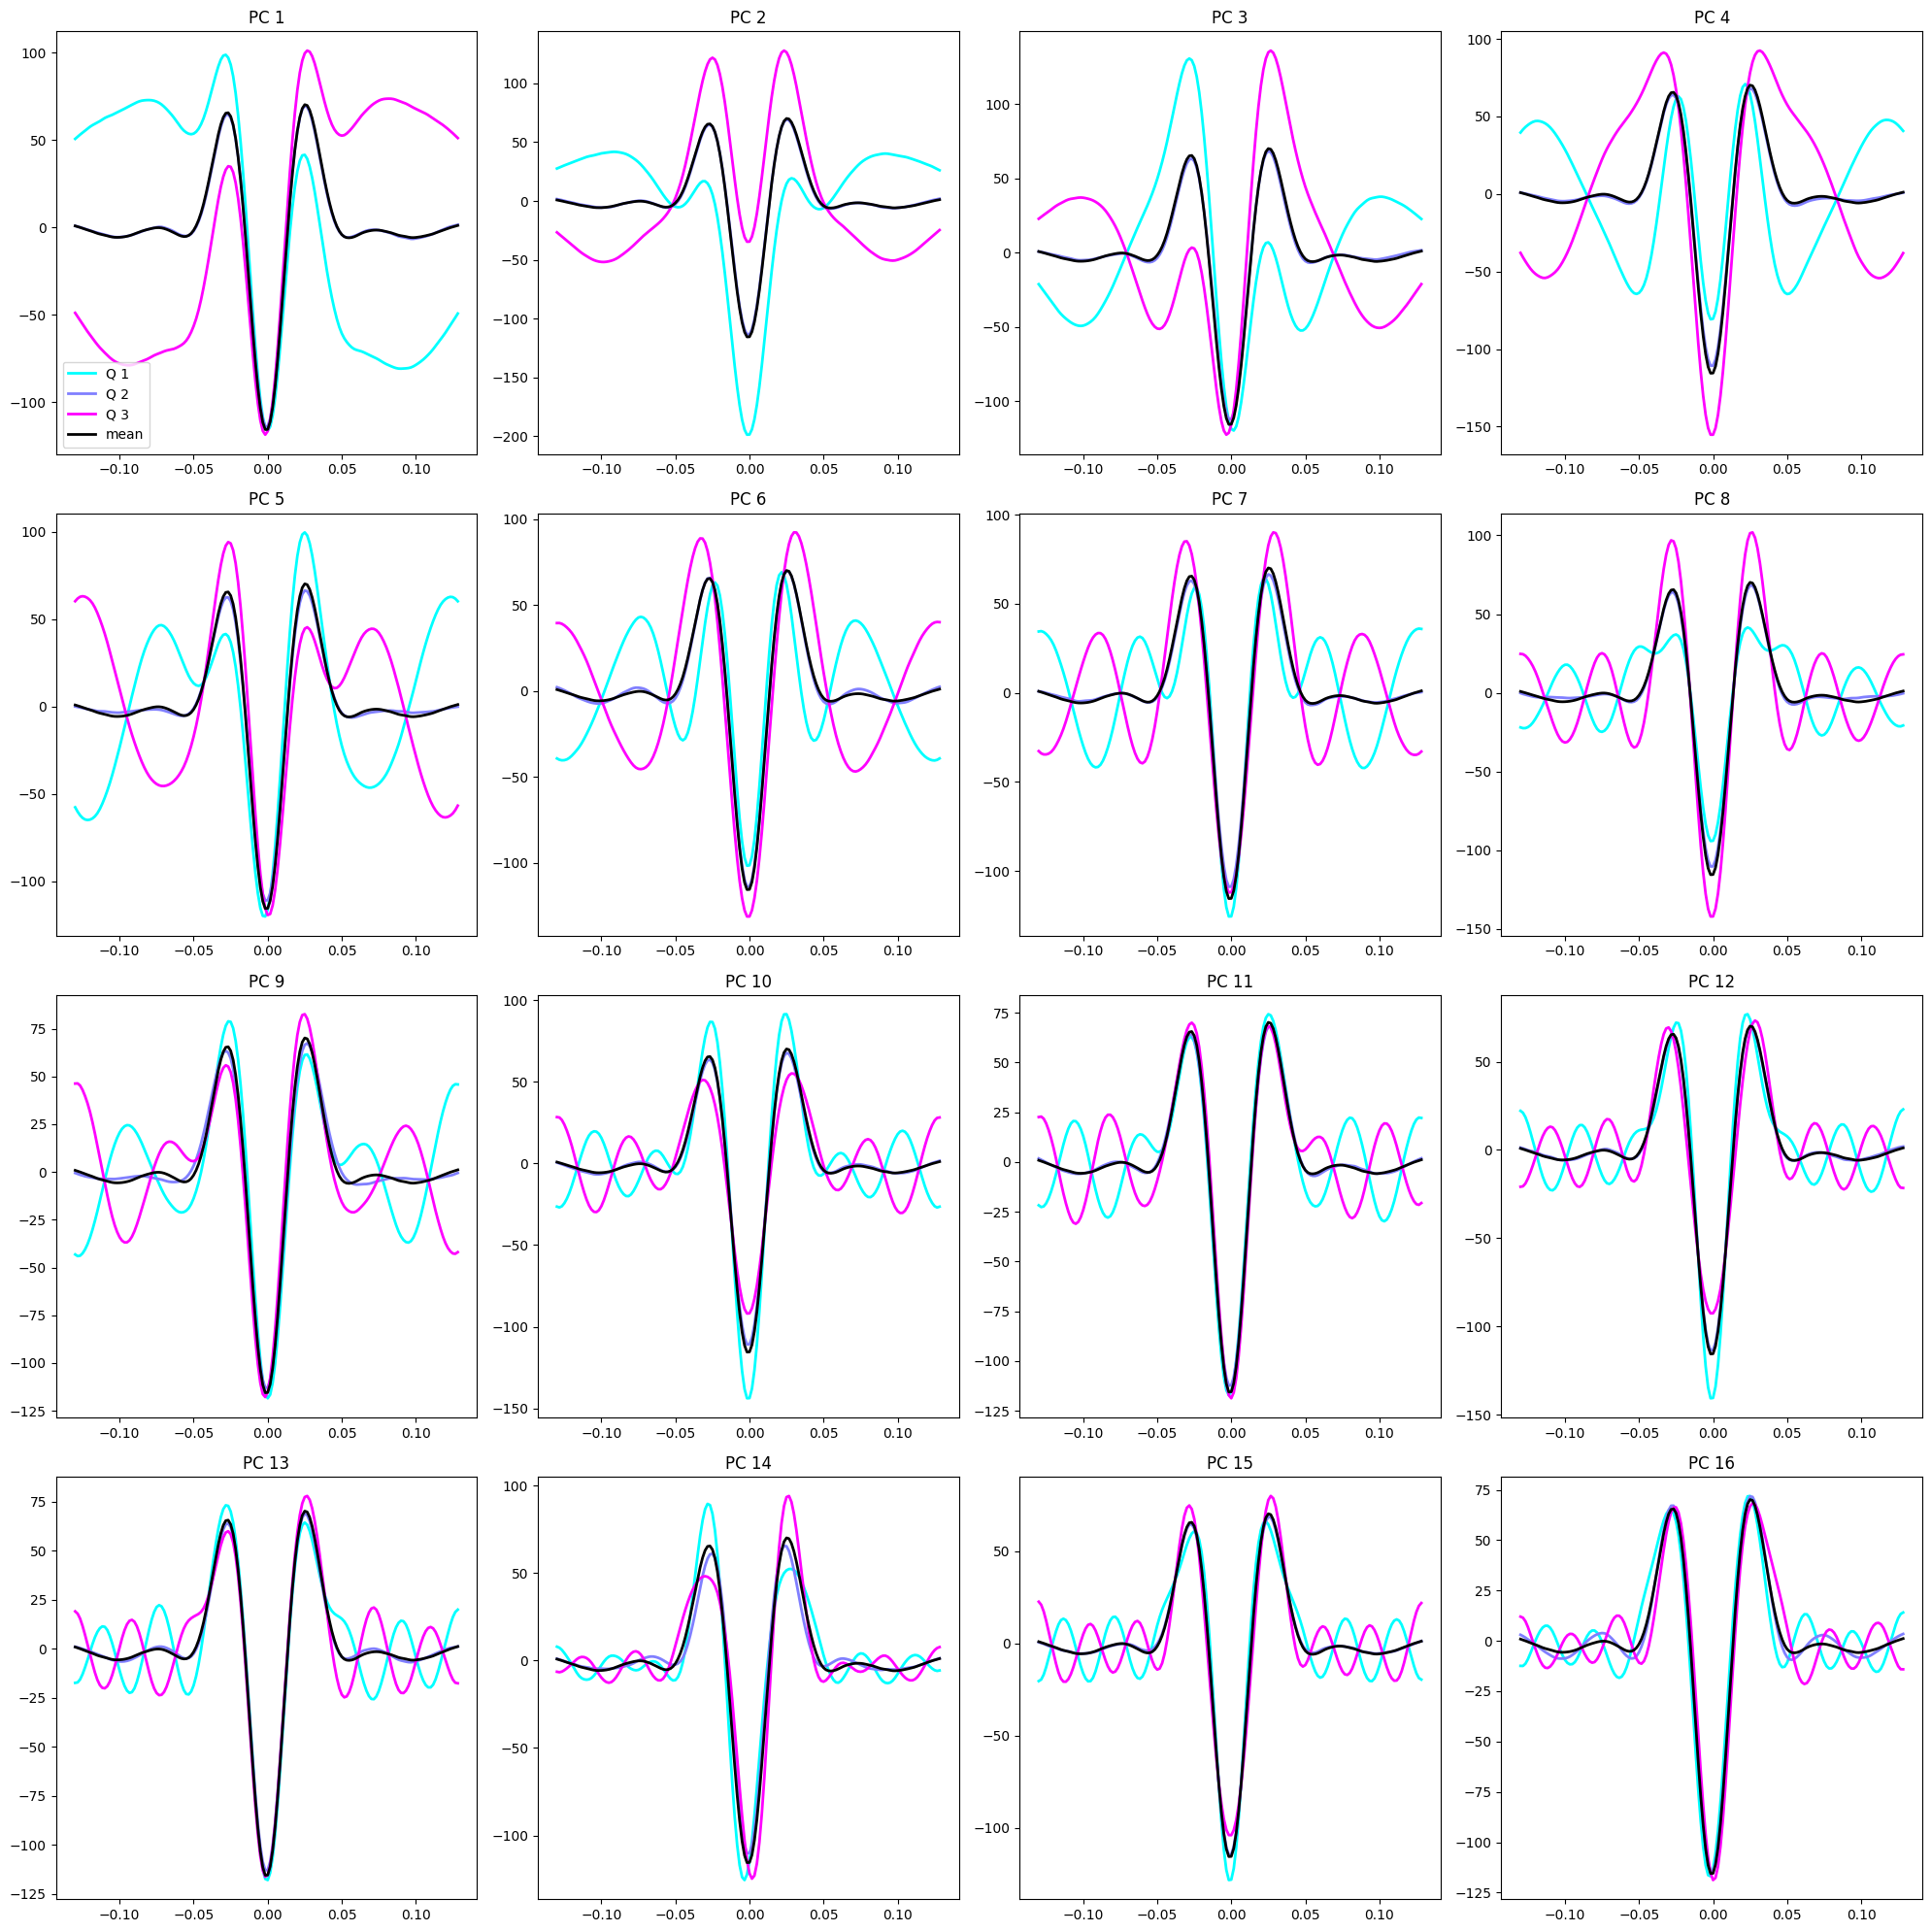

In [ ]:
waveforms=all_bursts['waveform']
model = PCA(n_components=20)
burst_std=np.zeros(waveforms.shape)
for subject in np.unique(all_bursts['subject_id']):
    s_idx=all_bursts['subject_id']==subject
    burst_std[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
burst_std = RobustScaler().fit_transform(burst_std)
model.fit(burst_std)
pc_scores = model.transform(burst_std)  # all the bursts x 20 components
pc_labels = ["PC_{}".format(i+1) for i in range(pc_scores.shape[1])]

n_q=3
quartiles = np.linspace(0, 100, num=n_q+1)
quartiles = list(zip(quartiles[:-1], quartiles[1:]))
col_range = plt.cm.cool(np.linspace(0, 1, num=len(quartiles)))
mean_waveform = np.mean(waveforms, axis=0)

f, ax = plt.subplots(4, 4, figsize=(20, 20))
ax = ax.flatten()
for pc_ix, pc in enumerate(pc_labels[:len(shuffling_results)]):
    ax[pc_ix].set_title(pc.replace("_", " "))  # set the nice title
    scores = pc_scores[:,pc_ix]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax[pc_ix].plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax[pc_ix].plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")
ax[0].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
df_dict={}
for key in all_bursts:
    if not (key=='waveform' or key=='waveform_times'):
        df_dict[key]=all_bursts[key]

for pc_idx in range(20):
    df_dict[pc_labels[pc_idx]]=pc_scores[:,pc_idx]
all_bursts_df = pd.DataFrame(df_dict)
#all_bursts_df.to_csv('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed/output/TD_contra_burst_features.csv', index=False)

In [ ]:
bin_width = 0.025
stim_time_bins = np.arange(-1.75, 1.75, bin_width)
resp_time_bins = np.arange(-1.75, 1.75, bin_width)

subject_score_ts={
    epoch_type: {
        condition: [] for condition in condition_names
    } for epoch_type in epoch_types
}
for subject_id in subject_ids:
    for epoch_type in epoch_types:
        for condition in condition_names:
            b_idx=(all_bursts['subject_id']==subject_id) & (all_bursts['epoch_type']==epoch_type) & (all_bursts['condition']==condition)
            pc_score_ts=[]
            for t_idx in range(len(stim_time_bins)-1):
                st=stim_time_bins[t_idx]
                en=stim_time_bins[t_idx+1]
                bb_idx=b_idx & (all_bursts['peak_time']>=st) & (all_bursts['peak_time']<=en)
                ms=np.nanmean(pc_scores[bb_idx,:],axis=0)
                pc_score_ts.append(ms)
            pc_score_ts=np.array(pc_score_ts)
            pc_score_ts = gaussian_filter1d(pc_score_ts, sigma=2.5, axis=0, mode="nearest")
            subject_score_ts[epoch_type][condition].append(pc_score_ts)

for epoch_type in epoch_types:
    for condition in condition_names:
        subject_score_ts[epoch_type][condition]=np.array(subject_score_ts[epoch_type][condition])

PC8 SHORT p=0.005499450054994501
PC8 LONG p=0.0006999300069993001


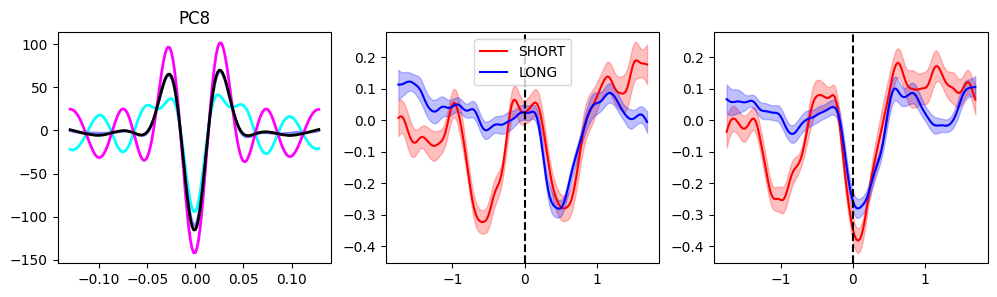

PC10 SHORT p=0.019498050194980503
PC10 LONG p=9.999000099990002e-05


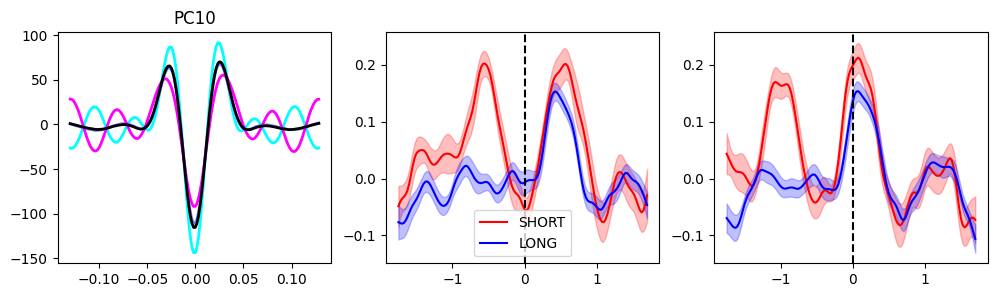

PC12 SHORT p=0.0022997700229977
PC12 LONG p=0.04179582041795821


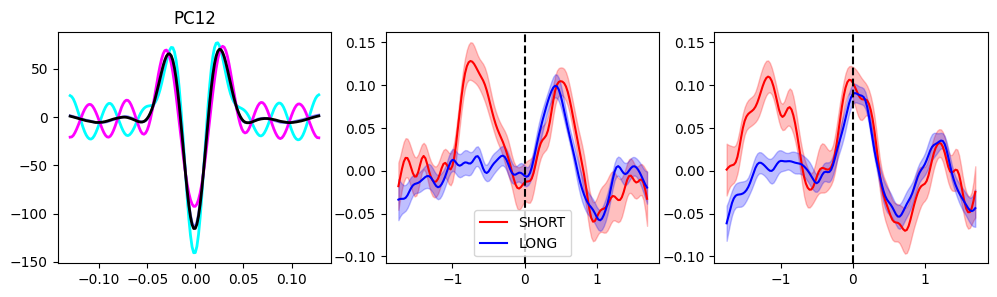

In [ ]:
n_perm = 10000  # number of permutations

# Boolean mask for STIM baseline (pre-0)
stim_baseline_mask = (stim_time_bins[:-1] > -1.5) & (stim_time_bins[:-1] < -1)
resp_mask = (stim_time_bins[:-1] > -0.4) & (stim_time_bins[:-1] < 0.2)

task_pcs=[]
obs_stats = {}

for pc in shuffling_results:
    m_stim_short = np.nanmean(subject_score_ts['STIM']['SHORT'], axis=0)[:, pc]
    se_stim_short = np.nanstd(subject_score_ts['STIM']['SHORT'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM']['SHORT'].shape[0])
    m_resp_short = np.nanmean(subject_score_ts['RESP']['SHORT'], axis=0)[:, pc]
    se_resp_short = np.nanstd(subject_score_ts['RESP']['SHORT'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP']['SHORT'].shape[0])
    
    m_stim_long = np.nanmean(subject_score_ts['STIM']['LONG'], axis=0)[:, pc]
    se_stim_long = np.nanstd(subject_score_ts['STIM']['LONG'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM']['LONG'].shape[0])
    m_resp_long = np.nanmean(subject_score_ts['RESP']['LONG'], axis=0)[:, pc]
    se_resp_long = np.nanstd(subject_score_ts['RESP']['LONG'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP']['LONG'].shape[0])
    
    # ------------------------------------------------------------------
    # Permutation test: is RESP temporal variance > STIM pre-0 variance?
    # ------------------------------------------------------------------
    stim_data_short = subject_score_ts['STIM']['SHORT'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data_short = subject_score_ts['RESP']['SHORT'][:, :, pc]  # shape: n_subj × n_time_resp
    stim_data_long = subject_score_ts['STIM']['LONG'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data_long = subject_score_ts['RESP']['LONG'][:, :, pc]  # shape: n_subj × n_time_resp

    # Per-subject temporal variances
    var_baseline_short = np.nanvar(stim_data_short[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp_short = np.nanvar(resp_data_short[:, resp_mask], axis=1, ddof=1)
    var_baseline_long = np.nanvar(stim_data_long[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp_long = np.nanvar(resp_data_long[:, resp_mask], axis=1, ddof=1)

    diff_short = var_resp_short - var_baseline_short              # ?_i
    diff_long = var_resp_long - var_baseline_long              # ?_i
    obs_stat_short = np.mean(diff_short)                    # observed mean difference across subjects
    obs_stat_long = np.mean(diff_long)                    # observed mean difference across subjects
    obs_stat_cond = obs_stat_long - obs_stat_short         # difference in differences (LONG - SHORT)
    
    obs_stats[pc] = {
        'SHORT':          obs_stat_short,
        'LONG':           obs_stat_long,
        'STIM_COND_DIFF': obs_stat_cond,
        'SHORT_SE':       np.std(diff_short) / np.sqrt(len(diff_short)),
        'LONG_SE':        np.std(diff_long)  / np.sqrt(len(diff_long)),
        'SHORT_SD':       np.std(diff_short),
        'LONG_SD':        np.std(diff_long),
        'N':              len(diff_short),
    }


    # Sign-flip permutation for paired test
    null_stats_short = np.zeros(n_perm)
    null_stats_long = np.zeros(n_perm)
    for p in range(n_perm):
        signs_short = np.random.choice([1, -1], size=diff_short.shape[0])
        signs_long = np.random.choice([1, -1], size=diff_long.shape[0])
        null_stats_short[p] = np.mean(diff_short * signs_short)
        null_stats_long[p] = np.mean(diff_long * signs_long)

    # One-sided p-value: H1 = RESP variance > baseline variance
    p_val_short = (np.sum(null_stats_short >= obs_stat_short) + 1) / (n_perm + 1)
    p_val_long = (np.sum(null_stats_long >= obs_stat_long) + 1) / (n_perm + 1)
    
    if p_val_short*len(shuffling_results)<0.05 or p_val_long*len(shuffling_results)<0.05:
        print(f'PC{pc+1} SHORT p={p_val_short}')
        print(f'PC{pc+1} LONG p={p_val_long}')
        task_pcs.append(pc)
        
        plt.figure(figsize=(12,3))

        ax=plt.subplot(1,3,1)
        ax.set_title(f'PC{pc+1}')  # set the nice title
        scores = pc_scores[:,pc]
        q_maps = []
        for q_ix, (b, e) in enumerate(quartiles):
            q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
            q_mean = np.mean(waveforms[q_map], axis=0)
            ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
        ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

        # STIM
        ax1 = plt.subplot(1,3,2)
        ax1.plot(stim_time_bins[:-1], m_stim_short, color='r', label='SHORT')
        ax1.fill_between(stim_time_bins[:-1], m_stim_short-se_stim_short, m_stim_short+se_stim_short, color='r', alpha=0.25)
        ax1.plot(stim_time_bins[:-1], m_stim_long, color='b', label='LONG')
        ax1.fill_between(stim_time_bins[:-1], m_stim_long-se_stim_long, m_stim_long+se_stim_long, color='b', alpha=0.25)
        ax1.axvline(0,color='k',linestyle='--')
        ax1.legend()
        yl1=ax1.get_ylim()

        # RESP
        ax2 = plt.subplot(1,3,3)
        ax2.plot(resp_time_bins[:-1], m_resp_short, color='r')
        ax2.fill_between(resp_time_bins[:-1], m_resp_short-se_resp_short, m_resp_short+se_resp_short, color='r', alpha=0.25)
        ax2.plot(resp_time_bins[:-1], m_resp_long, color='b')
        ax2.fill_between(resp_time_bins[:-1], m_resp_long-se_resp_long, m_resp_long+se_resp_long, color='b', alpha=0.25)
        ax2.axvline(0,color='k',linestyle='--')
        yl2=ax2.get_ylim()

        ymin=np.min([yl1[0], yl2[0]])
        ymax=np.max([yl1[1], yl2[1]])
        ax1.set_ylim(ymin, ymax)
        ax2.set_ylim(ymin, ymax)
        plt.show()

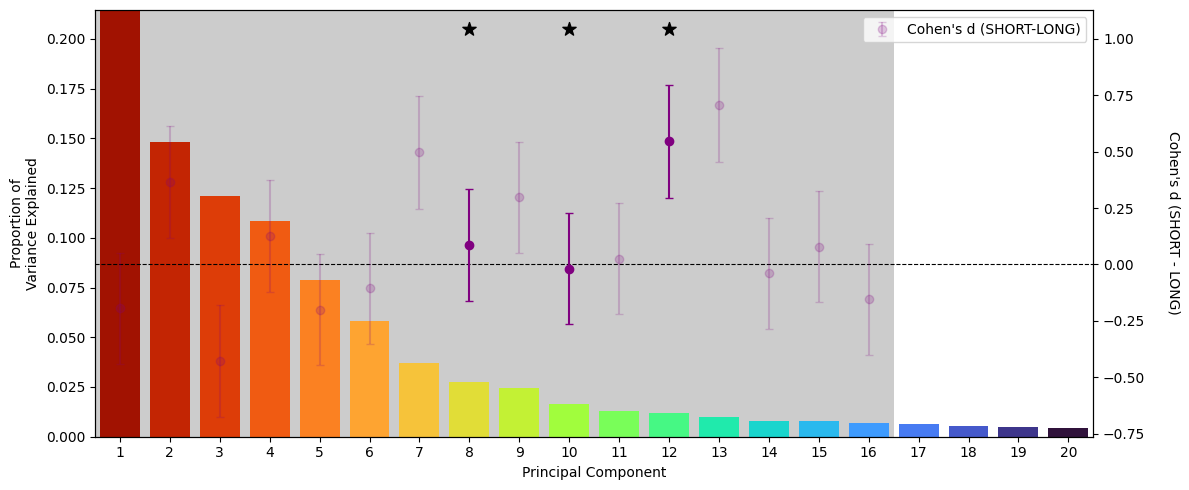

In [ ]:
plt.rcParams.update({'axes.spines.right': True})
fig, ax = plt.subplots(figsize=(12, 5))
PC_var_exp = model.explained_variance_ratio_
PC_r = np.arange(PC_var_exp.shape[0]) + 1

shuf_plot = np.zeros(PC_var_exp.shape[0])
shuf_plot[shuffling_results] = np.max(PC_var_exp)
ax.bar(PC_r, shuf_plot, lw=0.2, color="black", alpha=0.2, width=1)

bar = ax.bar(PC_r, PC_var_exp, lw=0.2)
cm = plt.colormaps["turbo_r"]
for i in PC_r:
    plt.setp(bar[i-1], "facecolor", cm(i/20))
ax.set_xlabel("Principal Component")
ax.set_ylabel("Proportion of\nVariance Explained")
ax.set_ylim([0, PC_var_exp[0]])
ax.set_xticks(PC_r)
ax.set_xlim(0.5, PC_r[-1] + 0.5)

ax2 = ax.twinx()
valid_pcs = [pc for pc in shuffling_results if pc in obs_stats]

cohen_d = []
cohen_d_se = []
for pc in valid_pcs:
    n         = obs_stats[pc]['N']
    pooled_sd = np.sqrt((obs_stats[pc]['SHORT_SD']**2 + obs_stats[pc]['LONG_SD']**2) / 2)
    d         = (obs_stats[pc]['SHORT'] - obs_stats[pc]['LONG']) / pooled_sd
    se_d      = np.sqrt(2/n + d**2 / (2*(2*n - 2)))
    cohen_d.append(d)
    cohen_d_se.append(se_d)

ax2.axhline(0, color='k', linestyle='--', lw=0.8)

# Plot each dot individually so we can control alpha per PC
for i, pc in enumerate(valid_pcs):
    alpha = 1.0 if pc in task_pcs else 0.2
    ax2.errorbar(pc + 1, cohen_d[i], yerr=cohen_d_se[i],
                 color='purple', fmt='o', capsize=3, alpha=alpha,
                 label="Cohen's d (SHORT-LONG)" if i == 0 else None)

# Stars all at same y: top of current ax2 range
ax2.figure.canvas.draw()  # force limits to settle
y_star = ax2.get_ylim()[1]
ax2.scatter(np.array(task_pcs) + 1,
            np.full(len(task_pcs), y_star),
            marker='*', color='k', s=100, zorder=5, clip_on=False)

ax2.set_ylabel("Cohen's d (SHORT - LONG)", rotation=-90, labelpad=25)
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

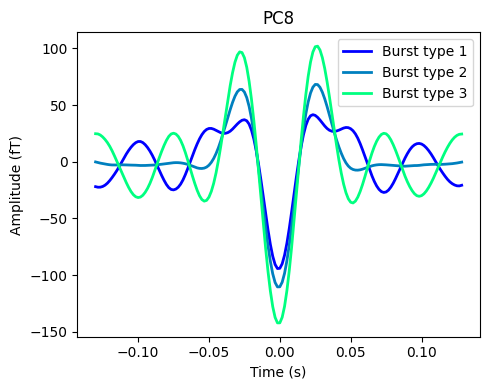

stat_fun(H1): min=-2.312981 max=3.633315
Running initial clustering …
Using 727 thresholds from 0.00 to 3.63 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC8 Burst type 1 - STIM SHORT
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0310, 0.0450]
    T range: [0.017, 0.018]
    Time: -0.550 - -0.500 s
    Size (pixels): 3
stat_fun(H1): min=-1.269905 max=3.986118
Running initial clustering …
Using 798 thresholds from 0.00 to 3.98 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC8 Burst type 2 - STIM SHORT
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0160, 0.0400]
    T range: [0.017, 0.020]
    Time: -0.925 - -0.800 s
    Size (pixels): 6
stat_fun(H1): min=-7.333097 max=3.185488
Running initial clustering …
Using 1467 thresholds from 0.00 to 7.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: PC8 Burst type 1 - RESP LONG
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0480]
    T range: [0.016, 0.035]
    Time: -0.075 - 0.400 s
    Size (pixels): 20
stat_fun(H1): min=-1.434866 max=5.655723
Running initial clustering …
Using 1132 thresholds from 0.00 to 5.66 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC8 Burst type 2 - RESP LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0370]
    T range: [0.017, 0.028]
    Time: -0.225 - -0.075 s
    Size (pixels): 7
  Region #2:
    p range: [0.0160, 0.0350]
    T range: [0.017, 0.020]
    Time: 0.100 - 0.200 s
    Size (pixels): 5
stat_fun(H1): min=-9.030976 max=1.855003
Running initial clustering …
Using 1807 thresholds from 0.00 to 9.03 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC8 Burst type 3 - RESP LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0200]
    T range: [-0.045, -0.018]
    Time: -0.100 - 0.375 s
    Size (pixels): 20
  Region #2:
    p range: [0.0040, 0.0400]
    T range: [-0.021, -0.017]
    Time: 1.275 - 1.425 s
    Size (pixels): 7


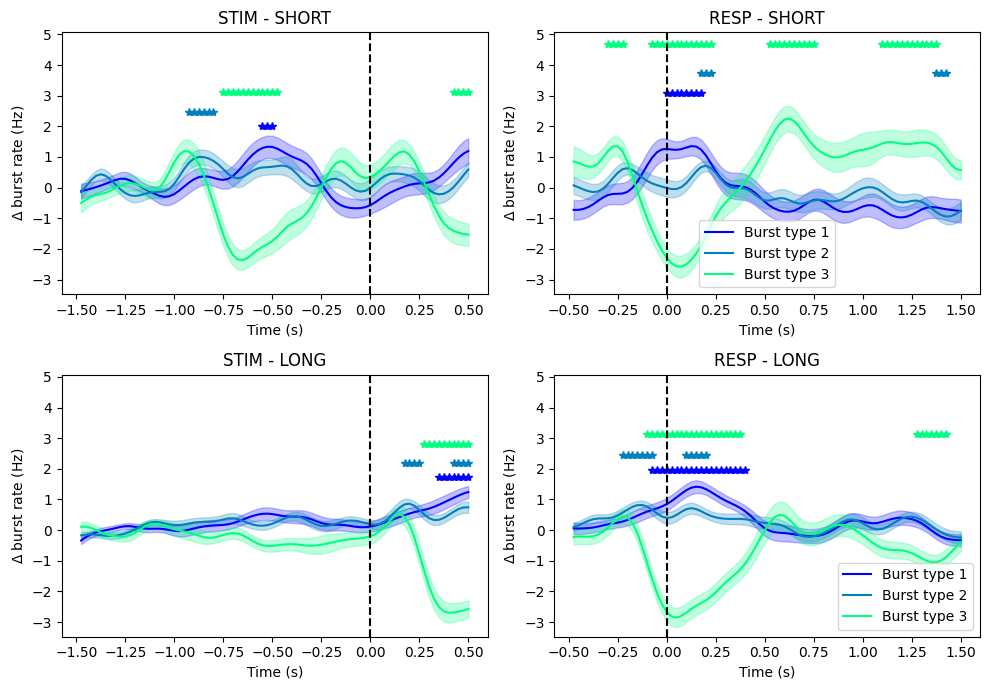

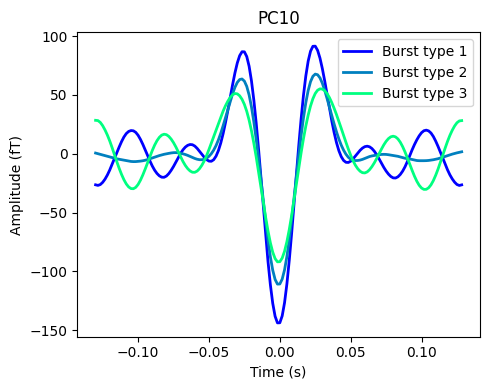

stat_fun(H1): min=-5.644688 max=2.643511
Running initial clustering …
Using 1129 thresholds from 0.00 to 5.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC10 Burst type 1 - STIM SHORT
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0200]
    T range: [-0.028, -0.019]
    Time: -0.700 - -0.450 s
    Size (pixels): 11
  Region #2:
    p range: [0.0050, 0.0380]
    T range: [-0.021, -0.018]
    Time: 0.350 - 0.425 s
    Size (pixels): 4
stat_fun(H1): min=-1.898233 max=3.460983
Running initial clustering …
Using 693 thresholds from 0.00 to 3.46 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC10 Burst type 2 - STIM SHORT
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0460, 0.0460]
    T range: [0.017, 0.017]
    Time: -0.425 - -0.425 s
    Size (pixels): 1
stat_fun(H1): min=-2.930057 max=4.090068
Running initial clustering …
Using 819 thresholds from 0.00 to 4.09 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: PC10 Burst type 1 - RESP LONG
  3 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0300]
    T range: [-0.046, -0.017]
    Time: -0.075 - 0.375 s
    Size (pixels): 19
  Region #2:
    p range: [0.0230, 0.0320]
    T range: [-0.018, -0.017]
    Time: 1.100 - 1.125 s
    Size (pixels): 2
  Region #3:
    p range: [0.0030, 0.0350]
    T range: [-0.023, -0.017]
    Time: 1.300 - 1.400 s
    Size (pixels): 5
stat_fun(H1): min=-3.217315 max=4.643128
Running initial clustering …
Using 929 thresholds from 0.00 to 4.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC10 Burst type 2 - RESP LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0050, 0.0290]
    T range: [0.018, 0.022]
    Time: -0.225 - -0.125 s
    Size (pixels): 5
  Region #2:
    p range: [0.0020, 0.0280]
    T range: [0.018, 0.023]
    Time: 0.100 - 0.250 s
    Size (pixels): 7
stat_fun(H1): min=-3.262194 max=4.636588
Running initial clustering …
Using 928 thresholds from 0.00 to 4.63 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC10 Burst type 3 - RESP LONG
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0030, 0.0380]
    T range: [0.017, 0.023]
    Time: 0.075 - 0.250 s
    Size (pixels): 8


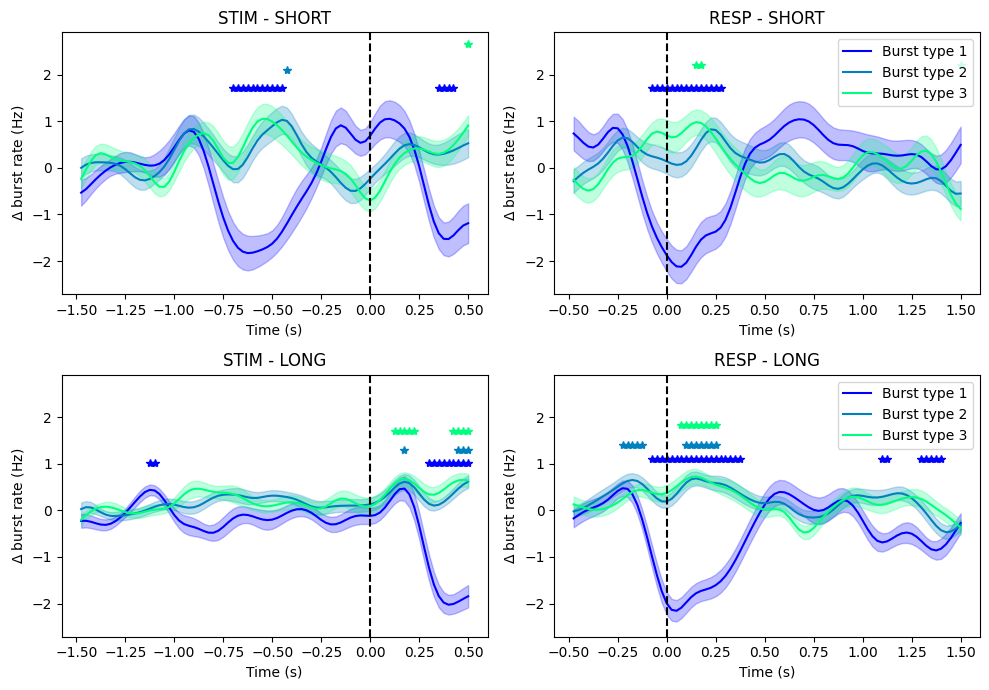

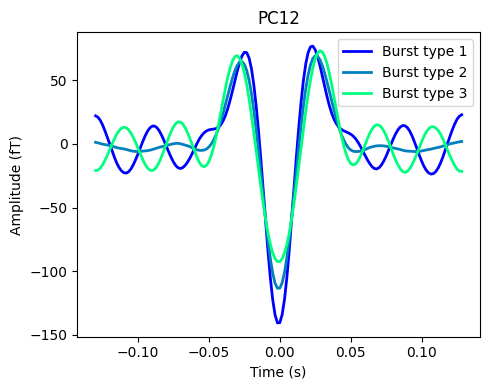

stat_fun(H1): min=-6.905074 max=1.879471
Running initial clustering …
Using 1382 thresholds from 0.00 to 6.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 Burst type 1 - STIM SHORT
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0140]
    T range: [-0.035, -0.020]
    Time: -0.775 - -0.575 s
    Size (pixels): 9
  Region #2:
    p range: [0.0040, 0.0290]
    T range: [-0.022, -0.018]
    Time: 0.400 - 0.500 s
    Size (pixels): 5
stat_fun(H1): min=-1.891596 max=4.576961
Running initial clustering …
Using 916 thresholds from 0.00 to 4.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 Burst type 2 - STIM SHORT
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0060, 0.0210]
    T range: [0.019, 0.023]
    Time: -0.950 - -0.850 s
    Size (pixels): 5
stat_fun(H1): min=-1.135923 max=6.239338
Running initial clustering …
Using 1248 thresholds from 0.00 to 6.24 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: PC12 Burst type 1 - RESP LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0380]
    T range: [-0.036, -0.018]
    Time: -0.100 - 0.250 s
    Size (pixels): 15
  Region #2:
    p range: [0.0040, 0.0430]
    T range: [-0.022, -0.017]
    Time: 1.300 - 1.400 s
    Size (pixels): 5
stat_fun(H1): min=-3.361715 max=5.074075
Running initial clustering …
Using 1015 thresholds from 0.00 to 5.07 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 Burst type 2 - RESP LONG
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0020, 0.0090]
    T range: [0.020, 0.025]
    Time: -0.200 - -0.100 s
    Size (pixels): 5
stat_fun(H1): min=-3.682459 max=4.817258
Running initial clustering …
Using 964 thresholds from 0.00 to 4.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 Burst type 3 - RESP LONG
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0040, 0.0350]
    T range: [0.018, 0.024]
    Time: -0.225 - -0.100 s
    Size (pixels): 6
  Region #2:
    p range: [0.0260, 0.0290]
    T range: [-0.018, -0.018]
    Time: 1.425 - 1.500 s
    Size (pixels): 4


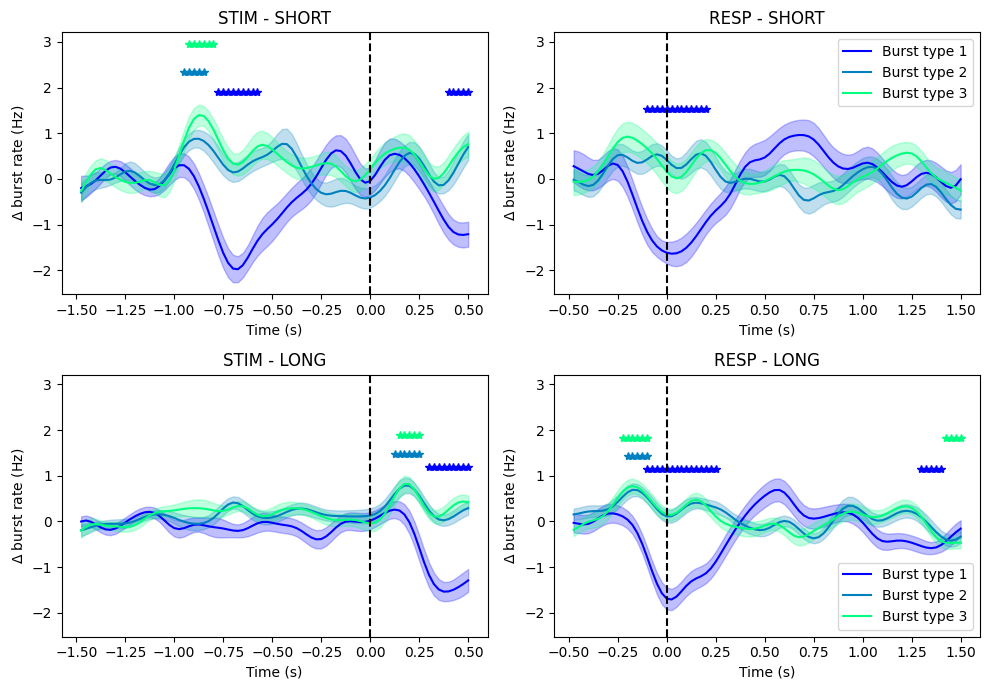

In [ ]:
step = 100 / n_q
stim_plt_idx=(stim_time_bins[:-1]>=-1.5) & (stim_time_bins[:-1]<=.5)
resp_plt_idx=(resp_time_bins[:-1]>=-.5) & (resp_time_bins[:-1]<=1.5)

stim_time_plt=stim_time_bins[:-1][stim_plt_idx]
resp_time_plt=resp_time_bins[:-1][resp_plt_idx]

threshold_tfce = dict(start=0, step=0.005)

# --- colormap: winter, n_q evenly spaced colors ---
cmap = plt.get_cmap('winter')
col_range = [cmap(x) for x in np.linspace(0, 1, n_q)]

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {
        q: {
            epoch_type: {
                condition: [] for condition in condition_names
            } for epoch_type in epoch_types
        } for q in range(n_q)
    }
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx
        resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))

            stim_short_idx = stim_b_idx & (all_bursts['condition']=='SHORT')
            resp_short_idx = resp_b_idx & (all_bursts['condition']=='SHORT')
            stim_long_idx = stim_b_idx & (all_bursts['condition']=='LONG')
            resp_long_idx = resp_b_idx & (all_bursts['condition']=='LONG')

            stim_short_trials = np.unique(all_bursts['trial'][stim_short_idx])
            resp_short_trials = np.unique(all_bursts['trial'][resp_short_idx])
            stim_long_trials = np.unique(all_bursts['trial'][stim_long_idx])
            resp_long_trials = np.unique(all_bursts['trial'][resp_long_idx])

            stim_short_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_short_idx & q_idx],
                bins=stim_time_bins
            )
            resp_short_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_short_idx & q_idx],
                bins=resp_time_bins
            )
            stim_long_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_long_idx & q_idx],
                bins=stim_time_bins
            )
            resp_long_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_long_idx & q_idx],
                bins=resp_time_bins
            )

            stim_short_unsmoothed_rate = (stim_short_unsmoothed_rate / bin_width) / len(stim_short_trials)
            resp_short_unsmoothed_rate = (resp_short_unsmoothed_rate / bin_width) / len(resp_short_trials)
            stim_long_unsmoothed_rate = (stim_long_unsmoothed_rate / bin_width) / len(stim_long_trials)
            resp_long_unsmoothed_rate = (resp_long_unsmoothed_rate / bin_width) / len(resp_long_trials)

            stim_short_smoothed_rate = gaussian_filter1d(stim_short_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_short_smoothed_rate = gaussian_filter1d(resp_short_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            stim_long_smoothed_rate = gaussian_filter1d(stim_long_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_long_smoothed_rate = gaussian_filter1d(resp_long_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins>=-1.5) & (stim_time_bins < -1))[0]

            base_rate = np.mean(stim_short_smoothed_rate[base_idx])
            stim_short_smoothed_rate = (stim_short_smoothed_rate - base_rate)[stim_plt_idx]
            resp_short_smoothed_rate = (resp_short_smoothed_rate - base_rate)[resp_plt_idx]
            base_rate = np.mean(stim_long_smoothed_rate[base_idx])
            stim_long_smoothed_rate = (stim_long_smoothed_rate - base_rate)[stim_plt_idx]
            resp_long_smoothed_rate = (resp_long_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['SHORT'].append(stim_short_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(resp_short_smoothed_rate)
            q_rates_smoothed[q]['STIM']['LONG'].append(stim_long_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(resp_long_smoothed_rate)

    # --- Figure 1: waveform, standalone ---
    fig_wave, ax_wave = plt.subplots(figsize=(5, 4))
    ax_wave.set_title(f'PC{pc+1}')
    scores = pc_scores[:,pc]
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax_wave.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label=f'Burst type {q_ix+1}')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude (fT)')
    ax_wave.legend()
    plt.tight_layout()
    plt.show()

    # --- Figure 2: burst rates, 2x2 grid ---
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7))

    # STIM SHORT
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM']['SHORT'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data, threshold=threshold_tfce, n_permutations=1000, tail=0, n_jobs=-1
        )
        print_cluster_results(stim_T_obs, stim_clusters, stim_cluster_p_values, None, stim_time_plt,
                              f"PC{pc+1} Burst type {q+1} - STIM SHORT")
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
    ax1.set_title('STIM - SHORT')
    ax1.axvline(0,color='k',linestyle='--')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel(r'$\Delta$ burst rate (Hz)')
    yl1=ax1.get_ylim()

    # RESP SHORT
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'Burst type {q+1}')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP']['SHORT'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data, threshold=threshold_tfce, n_permutations=1000, tail=0, n_jobs=-1
        )
        print_cluster_results(resp_T_obs, resp_clusters, resp_cluster_p_values, None, resp_time_plt,
                              f"PC{pc+1} Burst type {q+1} - RESP SHORT")
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
    ax2.legend()
    ax2.set_title('RESP - SHORT')
    ax2.axvline(0,color='k',linestyle='--')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel(r'$\Delta$ burst rate (Hz)')
    yl2=ax2.get_ylim()

    # STIM LONG
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
        ax3.plot(stim_time_plt, m_rate, color=col_range[q])
        ax3.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM']['LONG'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data, threshold=threshold_tfce, n_permutations=1000, tail=0, n_jobs=-1
        )
        print_cluster_results(stim_T_obs, stim_clusters, stim_cluster_p_values, None, stim_time_plt,
                              f"PC{pc+1} Burst type {q+1} - STIM LONG")
        yl = ax3.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax3.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
    ax3.set_title('STIM - LONG')
    ax3.axvline(0,color='k',linestyle='--')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel(r'$\Delta$ burst rate (Hz)')
    yl3=ax3.get_ylim()

    # RESP LONG
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
        ax4.plot(resp_time_plt, m_rate, color=col_range[q], label=f'Burst type {q+1}')
        ax4.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP']['LONG'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data, threshold=threshold_tfce, n_permutations=1000, tail=0, n_jobs=-1
        )
        print_cluster_results(resp_T_obs, resp_clusters, resp_cluster_p_values, None, resp_time_plt,
                              f"PC{pc+1} Burst type {q+1} - RESP LONG")
        yl = ax4.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax4.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
    ax4.legend()
    ax4.set_title('RESP - LONG')
    ax4.axvline(0,color='k',linestyle='--')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel(r'$\Delta$ burst rate (Hz)')
    yl4=ax4.get_ylim()

    ymin=np.min([yl1[0], yl2[0], yl3[0], yl4[0]])
    ymax=np.max([yl1[1], yl2[1], yl3[0], yl4[0]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    ax3.set_ylim(ymin, ymax)
    ax4.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.show()

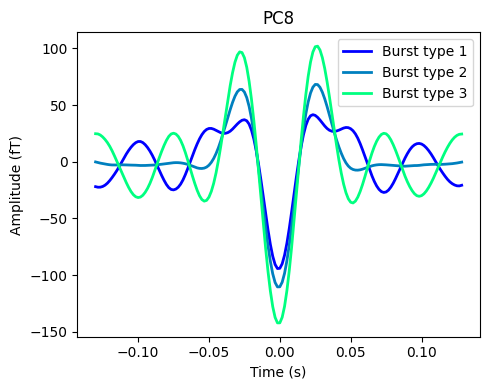

stat_fun(H1): min=-1.788132 max=1.990860
Running initial clustering …
Using 399 thresholds from 0.00 to 1.99 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.203338 max=3.069113
Running initial clustering …
Using 614 thresholds from 0.00 to 3.06 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC8 Burst type 1 - STIM LONG vs SHORT
No significant clusters (p < .05)

Cluster results: PC8 Burst type 1 - RESP LONG vs SHORT
No significant clusters (p < .05)
stat_fun(H1): min=-2.609886 max=2.199484
Running initial clustering …
Using 522 thresholds from 0.00 to 2.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: PC8 Burst type 2 - STIM LONG vs SHORT
No significant clusters (p < .05)

Cluster results: PC8 Burst type 2 - RESP LONG vs SHORT
No significant clusters (p < .05)
stat_fun(H1): min=-3.557024 max=5.797604
Running initial clustering …
Using 1160 thresholds from 0.00 to 5.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.180958 max=0.047683
Running initial clustering …
Using 1037 thresholds from 0.00 to 5.18 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC8 Burst type 3 - STIM LONG vs SHORT
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0010, 0.0400]
    T range: [0.018, 0.029]
    Time: -0.725 - -0.550 s
    Size (pixels): 8
  Region #2:
    p range: [0.0420, 0.0440]
    T range: [-0.018, -0.018]
    Time: 0.300 - 0.325 s
    Size (pixels): 2

Cluster results: PC8 Burst type 3 - RESP LONG vs SHORT
  2 contiguous significant region(s) found

  Region #1:
    p range: [0.0020, 0.0460]
    T range: [-0.025, -0.017]
    Time: 0.600 - 0.750 s
    Size (pixels): 7
  Region #2:
    p range: [0.0020, 0.0430]
    T range: [-0.026, -0.017]
    Time: 1.075 - 1.450 s
    Size (pixels): 16


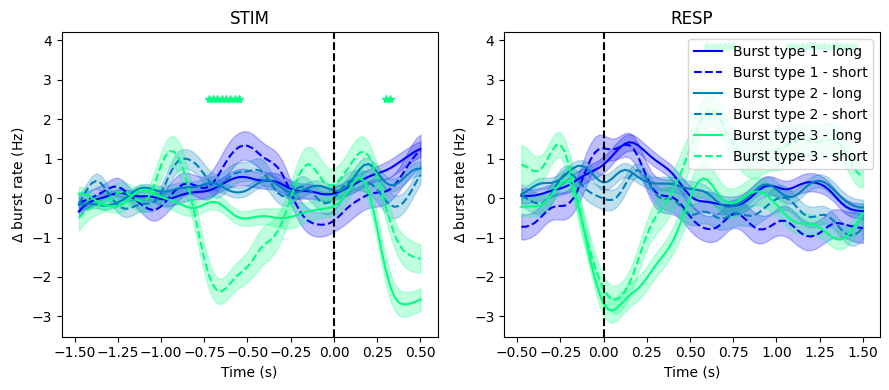

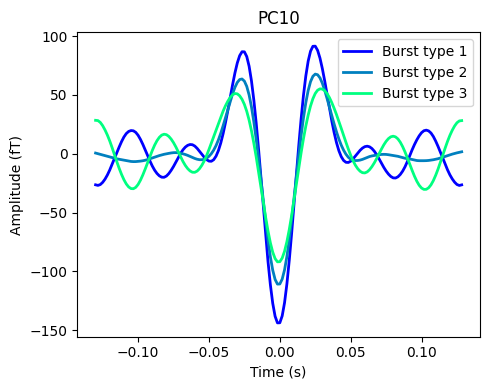

stat_fun(H1): min=-2.752170 max=4.719170
Running initial clustering …
Using 944 thresholds from 0.00 to 4.71 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.038079 max=1.319288
Running initial clustering …
Using 608 thresholds from 0.00 to 3.04 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC10 Burst type 1 - STIM LONG vs SHORT
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0030, 0.0220]
    T range: [0.019, 0.024]
    Time: -0.650 - -0.450 s
    Size (pixels): 9

Cluster results: PC10 Burst type 1 - RESP LONG vs SHORT
No significant clusters (p < .05)
stat_fun(H1): min=-2.279065 max=1.812463
Running initial clustering …
Using 456 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: PC10 Burst type 2 - STIM LONG vs SHORT
No significant clusters (p < .05)

Cluster results: PC10 Burst type 2 - RESP LONG vs SHORT
No significant clusters (p < .05)
stat_fun(H1): min=-2.667744 max=2.583167
Running initial clustering …
Using 534 thresholds from 0.00 to 2.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.438461 max=1.668753
Running initial clustering …
Using 334 thresholds from 0.00 to 1.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC10 Burst type 3 - STIM LONG vs SHORT
No significant clusters (p < .05)

Cluster results: PC10 Burst type 3 - RESP LONG vs SHORT
No significant clusters (p < .05)


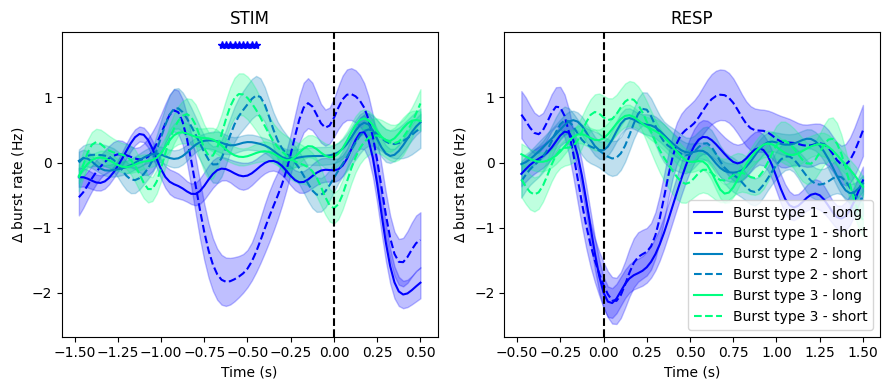

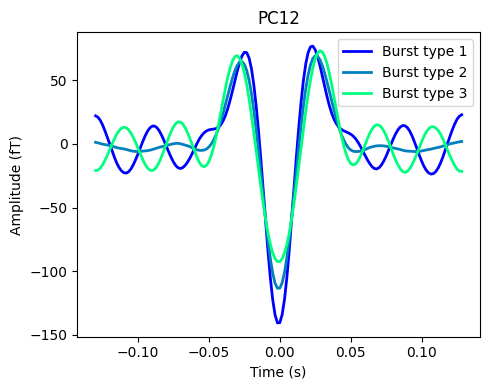

stat_fun(H1): min=-2.769142 max=5.128052
Running initial clustering …
Using 1026 thresholds from 0.00 to 5.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.278667 max=1.087440
Running initial clustering …
Using 456 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 Burst type 1 - STIM LONG vs SHORT
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0020, 0.0290]
    T range: [0.018, 0.026]
    Time: -0.750 - -0.600 s
    Size (pixels): 7

Cluster results: PC12 Burst type 1 - RESP LONG vs SHORT
No significant clusters (p < .05)
stat_fun(H1): min=-3.726633 max=1.889561
Running initial clustering …
Using 746 thresholds from 0.00 to 3.73 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...


Cluster results: PC12 Burst type 2 - STIM LONG vs SHORT
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0230, 0.0350]
    T range: [-0.019, -0.018]
    Time: -0.925 - -0.875 s
    Size (pixels): 3

Cluster results: PC12 Burst type 2 - RESP LONG vs SHORT
No significant clusters (p < .05)
stat_fun(H1): min=-4.388971 max=1.261272
Running initial clustering …
Using 878 thresholds from 0.00 to 4.38 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.912451 max=1.215967
Running initial clustering …
Using 383 thresholds from 0.00 to 1.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 Burst type 3 - STIM LONG vs SHORT
  1 contiguous significant region(s) found

  Region #1:
    p range: [0.0060, 0.0130]
    T range: [-0.022, -0.020]
    Time: -0.875 - -0.825 s
    Size (pixels): 3

Cluster results: PC12 Burst type 3 - RESP LONG vs SHORT
No significant clusters (p < .05)


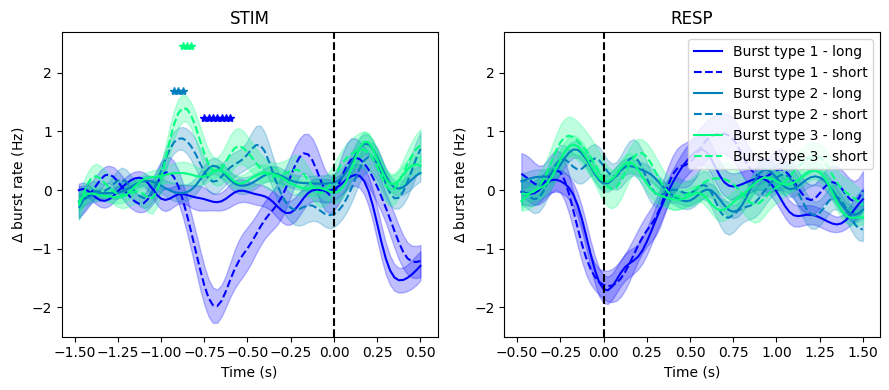

In [ ]:
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)

# --- colormap: winter, n_q evenly spaced colors ---
cmap = plt.get_cmap('winter')
col_range = [cmap(x) for x in np.linspace(0, 1, n_q)]

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        long_stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=(all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=(all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins>=-1.5) & (stim_time_bins < -1))[0]

            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            base_rate = np.mean(short_stim_smoothed_rate[base_idx])
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)

    # --- Figure 1: waveform, standalone ---
    fig_wave, ax_wave = plt.subplots(figsize=(5, 4))
    ax_wave.set_title(f'PC{pc+1}')
    scores = pc_scores[:,pc]
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax_wave.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label=f'Burst type {q_ix+1}')
    ax_wave.set_xlabel('Time (s)')
    ax_wave.set_ylabel('Amplitude (fT)')
    ax_wave.legend()
    plt.tight_layout()
    plt.show()

    # --- Figure 2: burst rates, STIM & RESP side by side ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        print_cluster_results(stim_T_obs, stim_clusters, stim_cluster_p_values, None, stim_time_plt,
                              f"PC{pc+1} Burst type {q+1} - STIM LONG vs SHORT")
        print_cluster_results(resp_T_obs, resp_clusters, resp_cluster_p_values, None, resp_time_plt,
                              f"PC{pc+1} Burst type {q+1} - RESP LONG vs SHORT")

        m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
        ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        # Plot significant clusters
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.1 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])

        m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'Burst type {q+1} - long')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
        ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'Burst type {q+1} - short')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

        ax2.legend()
        # Plot significant clusters
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.1 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])

    ax1.axvline(0,color='k',linestyle='--')
    ax1.set_title('STIM')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel(r'$\Delta$ burst rate (Hz)')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    ax2.set_title('RESP')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel(r'$\Delta$ burst rate (Hz)')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.show()

stat_fun(H1): min=-1.913866 max=2.317982
Running initial clustering …
Using 464 thresholds from 0.00 to 2.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T1 STIM SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.548691 max=1.582404
Running initial clustering …
Using 510 thresholds from 0.00 to 2.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T1 STIM LONG: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-1.127469 max=1.738480
Running initial clustering …
Using 348 thresholds from 0.00 to 1.74 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T1 RESP SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.895732 max=1.078839
Running initial clustering …
Using 580 thresholds from 0.00 to 2.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T1 RESP LONG: high vs low age
No significant clusters (p < .05)


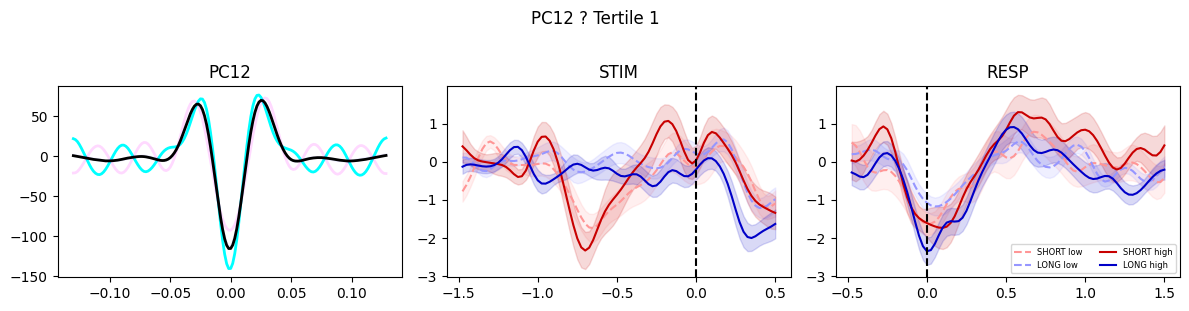

stat_fun(H1): min=-2.867806 max=1.008028
Running initial clustering …
Using 574 thresholds from 0.00 to 2.87 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T2 STIM SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.316505 max=2.310632
Running initial clustering …
Using 464 thresholds from 0.00 to 2.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T2 STIM LONG: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-1.644098 max=1.180937
Running initial clustering …
Using 329 thresholds from 0.00 to 1.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T2 RESP SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.191350 max=1.247975
Running initial clustering …
Using 439 thresholds from 0.00 to 2.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T2 RESP LONG: high vs low age
No significant clusters (p < .05)


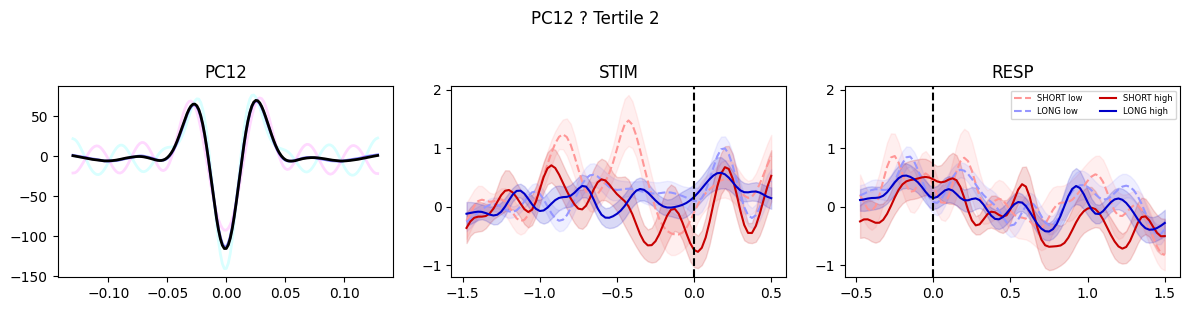

stat_fun(H1): min=-1.184551 max=1.545269
Running initial clustering …
Using 310 thresholds from 0.00 to 1.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T3 STIM SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-2.550284 max=2.336823
Running initial clustering …
Using 511 thresholds from 0.00 to 2.55 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T3 STIM LONG: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-1.207546 max=1.046508
Running initial clustering …
Using 242 thresholds from 0.00 to 1.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T3 RESP SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-0.814481 max=2.389053
Running initial clustering …
Using 478 thresholds from 0.00 to 2.39 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T3 RESP LONG: high vs low age
No significant clusters (p < .05)


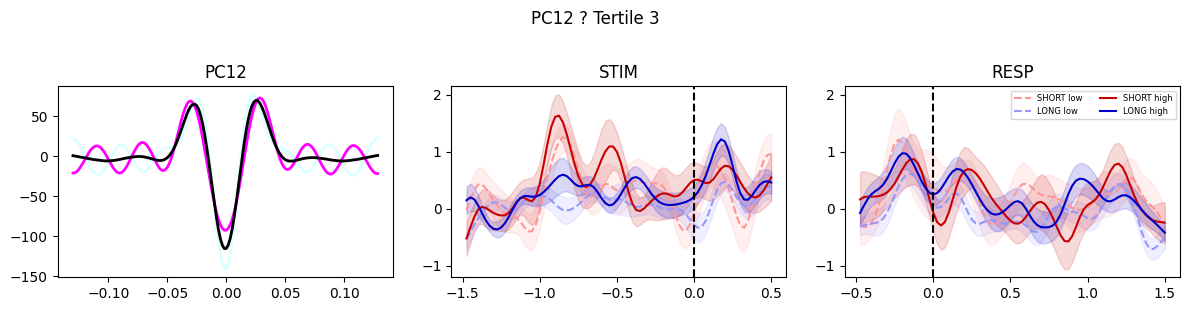

In [ ]:
step = 100 / n_q

def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

def ttest_ind_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_ind(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
ind_t    = partial(ttest_ind_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)

low_subject_ids  = [s for s in subject_ids if age_lookup.get(s, np.nan) <= median_age]
high_subject_ids = [s for s in subject_ids if age_lookup.get(s, np.nan) >  median_age]
age_groups = {'low': low_subject_ids, 'high': high_subject_ids}
age_colors = {'low': {'SHORT': np.array([255,150,150])/255, 'LONG': np.array([150,150,255])/255},
              'high': {'SHORT': np.array([200,0,0])/255,    'LONG': np.array([0,0,200])/255}}
age_ls     = {'low': '--', 'high': '-'}

pc = 11  # PC12
q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

q_rates_smoothed = {
    age: {q: {ep: {c: [] for c in condition_names} for ep in epoch_types} for q in range(n_q)}
    for age in age_groups
}

for age_label, age_subj_ids in age_groups.items():
    for subject_id in age_subj_ids:
        subj_idx         = (all_bursts['subject_id'] == subject_id)
        long_stim_b_idx  = subj_idx & stim_idx & (all_bursts['condition'] == 'LONG')
        short_stim_b_idx = subj_idx & stim_idx & (all_bursts['condition'] == 'SHORT')
        long_resp_b_idx  = subj_idx & resp_idx & (all_bursts['condition'] == 'LONG')
        short_resp_b_idx = subj_idx & resp_idx & (all_bursts['condition'] == 'SHORT')

        long_stim_trials  = np.unique(all_bursts['trial'][long_stim_b_idx])
        short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
        long_resp_trials  = np.unique(all_bursts['trial'][long_resp_b_idx])
        short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])
        if any(len(t) == 0 for t in [long_stim_trials, short_stim_trials,
                                      long_resp_trials, short_resp_trials]):
            continue

        for q in range(n_q):
            q_idx = (pc_scores[:, pc] >= q_bins[q]) & (pc_scores[:, pc] <= q_bins[q+1])

            def get_rate(b_idx, time_bins, n_trials):
                r, _ = np.histogram(all_bursts['peak_time'][subj_idx & b_idx & q_idx], bins=time_bins)
                return gaussian_filter1d((r / bin_width) / n_trials, sigma=2.5, mode='nearest')

            long_stim_r  = get_rate(long_stim_b_idx,  stim_time_bins, len(long_stim_trials))
            short_stim_r = get_rate(short_stim_b_idx, stim_time_bins, len(short_stim_trials))
            long_resp_r  = get_rate(long_resp_b_idx,  resp_time_bins, len(long_resp_trials))
            short_resp_r = get_rate(short_resp_b_idx, resp_time_bins, len(short_resp_trials))

            base_idx_mask = np.where((stim_time_bins >= -1.5) & (stim_time_bins < -1))[0]

            base = np.mean(long_stim_r[base_idx_mask])
            q_rates_smoothed[age_label][q]['STIM']['LONG'].append((long_stim_r - base)[stim_plt_idx])
            q_rates_smoothed[age_label][q]['RESP']['LONG'].append((long_resp_r - base)[resp_plt_idx])
            base = np.mean(short_stim_r[base_idx_mask])
            q_rates_smoothed[age_label][q]['STIM']['SHORT'].append((short_stim_r - base)[stim_plt_idx])
            q_rates_smoothed[age_label][q]['RESP']['SHORT'].append((short_resp_r - base)[resp_plt_idx])

# --- One figure per tertile ---
for q in range(n_q):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    fig.suptitle(f'PC{pc+1} ? Tertile {q+1}', y=1.02)

    # Left: waveform
    ax = axes[0]
    scores = pc_scores[:, pc]
    for q_ix, (b, e) in enumerate(quartiles):
        q_map  = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))
        q_mean = np.mean(waveforms[q_map], axis=0)
        alpha  = 1.0 if q_ix == q else 0.15
        ax.plot(waveform_times, q_mean / 1e-15, lw=2, c=col_range[q_ix],
                label=f'Q {q_ix+1}', alpha=alpha)
    ax.plot(waveform_times, mean_waveform / 1e-15, lw=2, c='black', label='mean')
    ax.set_title(f'PC{pc+1}')

    ax1 = axes[1]
    ax1.set_title('STIM')
    ax2 = axes[2]
    ax2.set_title('RESP')

    for ax_plt, epoch, time_plt in [(ax1, 'STIM', stim_time_plt),
                                     (ax2, 'RESP', resp_time_plt)]:
        handles = []
        for age_label in ['low', 'high']:
            for condition in ['SHORT', 'LONG']:
                data = np.array(q_rates_smoothed[age_label][q][epoch][condition])
                if len(data) == 0:
                    continue
                m   = np.mean(data, axis=0)
                se  = np.std(data,  axis=0) / np.sqrt(len(data))
                col = age_colors[age_label][condition]
                ls  = age_ls[age_label]
                l,  = ax_plt.plot(time_plt, m, ls, color=col,
                                  label=f'{condition} {age_label}')
                ax_plt.fill_between(time_plt, m - se, m + se, color=col, alpha=0.15)
                handles.append(l)

        # --- Age diff stats: high vs low, per condition ---
        for condition, y_sign in [('SHORT', 1), ('LONG', -1)]:
            d_high = np.array(q_rates_smoothed['high'][q][epoch][condition])
            d_low  = np.array(q_rates_smoothed['low'][q][epoch][condition])
            if len(d_high) < 3 or len(d_low) < 3:
                continue
            _, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
                [d_high, d_low], stat_fun=ind_t, threshold=threshold_tfce,
                n_permutations=1000, tail=0, n_jobs=-1
            )
            print_cluster_results(_, clusters, cluster_p_values, None, time_plt,
                                  f'PC{pc+1} T{q+1} {epoch} {condition}: high vs low age')
            yl  = ax_plt.get_ylim()
            py  = yl[1] + y_sign * 0.08 * (yl[1] - yl[0])
            col = age_colors['high'][condition]
            for clu, p_val in zip(clusters, cluster_p_values):
                if p_val < 0.05:
                    ax_plt.plot(time_plt[clu[0]], np.full(len(clu[0]), py),
                                color=col, lw=3)

        ax_plt.axvline(0, color='k', linestyle='--')

    ax2.legend(handles=handles, fontsize=6, ncol=2)

    ymin = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
    ymax = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.show()

stat_fun(H1): min=-1.913866 max=2.317982
Running initial clustering …
Using 464 thresholds from 0.00 to 2.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T1 STIM SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-1.127469 max=1.738480
Running initial clustering …
Using 348 thresholds from 0.00 to 1.74 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T1 RESP SHORT: high vs low age
No significant clusters (p < .05)


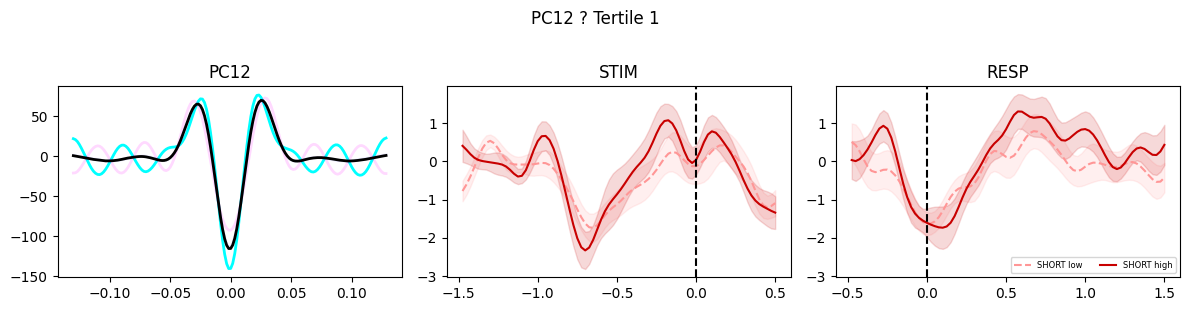

stat_fun(H1): min=-2.867806 max=1.008028
Running initial clustering …
Using 574 thresholds from 0.00 to 2.87 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T2 STIM SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-1.644098 max=1.180937
Running initial clustering …
Using 329 thresholds from 0.00 to 1.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T2 RESP SHORT: high vs low age
No significant clusters (p < .05)


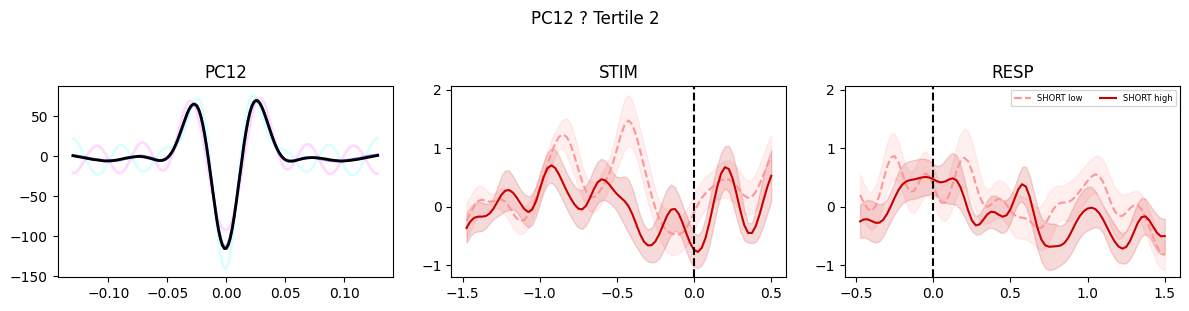

stat_fun(H1): min=-1.184551 max=1.545269
Running initial clustering …
Using 310 thresholds from 0.00 to 1.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T3 STIM SHORT: high vs low age
No significant clusters (p < .05)
stat_fun(H1): min=-1.207546 max=1.046508
Running initial clustering …
Using 242 thresholds from 0.00 to 1.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]


Cluster results: PC12 T3 RESP SHORT: high vs low age
No significant clusters (p < .05)


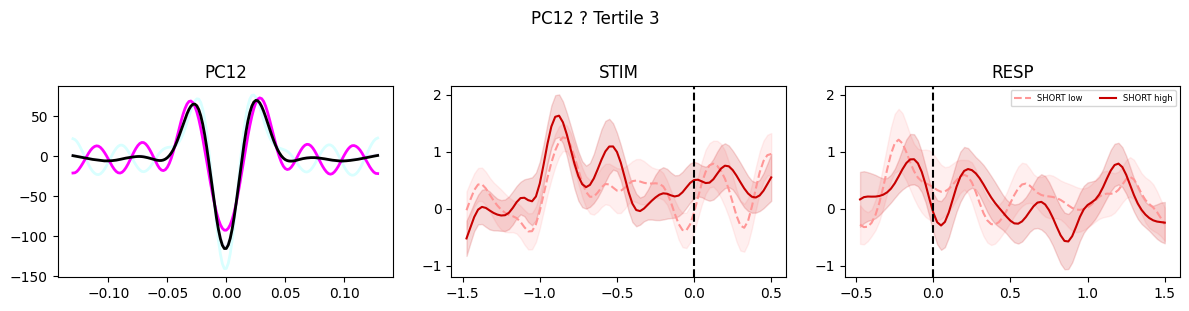

In [ ]:
step = 100 / n_q

def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

def ttest_ind_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_ind(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
ind_t    = partial(ttest_ind_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)

low_subject_ids  = [s for s in subject_ids if age_lookup.get(s, np.nan) <= median_age]
high_subject_ids = [s for s in subject_ids if age_lookup.get(s, np.nan) >  median_age]
age_groups = {'low': low_subject_ids, 'high': high_subject_ids}
age_colors = {'low':  {'SHORT': np.array([255,150,150])/255, 'LONG': np.array([150,150,255])/255},
              'high': {'SHORT': np.array([200,0,0])/255,     'LONG': np.array([0,0,200])/255}}
age_ls = {'low': '--', 'high': '-'}

pc = 11  # PC12
q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

q_rates_smoothed = {
    age: {q: {ep: {c: [] for c in condition_names} for ep in epoch_types} for q in range(n_q)}
    for age in age_groups
}

for age_label, age_subj_ids in age_groups.items():
    for subject_id in age_subj_ids:
        subj_idx         = (all_bursts['subject_id'] == subject_id)
        long_stim_b_idx  = subj_idx & stim_idx & (all_bursts['condition'] == 'LONG')
        short_stim_b_idx = subj_idx & stim_idx & (all_bursts['condition'] == 'SHORT')
        long_resp_b_idx  = subj_idx & resp_idx & (all_bursts['condition'] == 'LONG')
        short_resp_b_idx = subj_idx & resp_idx & (all_bursts['condition'] == 'SHORT')

        long_stim_trials  = np.unique(all_bursts['trial'][long_stim_b_idx])
        short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
        long_resp_trials  = np.unique(all_bursts['trial'][long_resp_b_idx])
        short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])
        if any(len(t) == 0 for t in [long_stim_trials, short_stim_trials,
                                      long_resp_trials, short_resp_trials]):
            continue

        for q in range(n_q):
            q_idx = (pc_scores[:, pc] >= q_bins[q]) & (pc_scores[:, pc] <= q_bins[q+1])

            def get_rate(b_idx, time_bins, n_trials):
                r, _ = np.histogram(all_bursts['peak_time'][subj_idx & b_idx & q_idx], bins=time_bins)
                return gaussian_filter1d((r / bin_width) / n_trials, sigma=2.5, mode='nearest')

            long_stim_r  = get_rate(long_stim_b_idx,  stim_time_bins, len(long_stim_trials))
            short_stim_r = get_rate(short_stim_b_idx, stim_time_bins, len(short_stim_trials))
            long_resp_r  = get_rate(long_resp_b_idx,  resp_time_bins, len(long_resp_trials))
            short_resp_r = get_rate(short_resp_b_idx, resp_time_bins, len(short_resp_trials))

            base_idx_mask = np.where((stim_time_bins >= -1.5) & (stim_time_bins < -1))[0]

            base = np.mean(long_stim_r[base_idx_mask])
            q_rates_smoothed[age_label][q]['STIM']['LONG'].append((long_stim_r - base)[stim_plt_idx])
            q_rates_smoothed[age_label][q]['RESP']['LONG'].append((long_resp_r - base)[resp_plt_idx])
            base = np.mean(short_stim_r[base_idx_mask])
            q_rates_smoothed[age_label][q]['STIM']['SHORT'].append((short_stim_r - base)[stim_plt_idx])
            q_rates_smoothed[age_label][q]['RESP']['SHORT'].append((short_resp_r - base)[resp_plt_idx])

# --- One figure per tertile ---
for q in range(n_q):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    fig.suptitle(f'PC{pc+1} ? Tertile {q+1}', y=1.02)

    ax = axes[0]
    scores = pc_scores[:, pc]
    for q_ix, (b, e) in enumerate(quartiles):
        q_map  = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))
        q_mean = np.mean(waveforms[q_map], axis=0)
        alpha  = 1.0 if q_ix == q else 0.15
        ax.plot(waveform_times, q_mean / 1e-15, lw=2, c=col_range[q_ix],
                label=f'Q {q_ix+1}', alpha=alpha)
    ax.plot(waveform_times, mean_waveform / 1e-15, lw=2, c='black', label='mean')
    ax.set_title(f'PC{pc+1}')

    ax1 = axes[1]
    ax1.set_title('STIM')
    ax2 = axes[2]
    ax2.set_title('RESP')

    for ax_plt, epoch, time_plt in [(ax1, 'STIM', stim_time_plt),
                                     (ax2, 'RESP', resp_time_plt)]:
        handles = []
        for age_label in ['low', 'high']:
            for condition in ['SHORT']:
                data = np.array(q_rates_smoothed[age_label][q][epoch][condition])
                if len(data) == 0:
                    continue
                m   = np.mean(data, axis=0)
                se  = np.std(data,  axis=0) / np.sqrt(len(data))
                col = age_colors[age_label][condition]
                ls  = age_ls[age_label]
                l,  = ax_plt.plot(time_plt, m, ls, color=col,
                                  label=f'{condition} {age_label}')
                ax_plt.fill_between(time_plt, m - se, m + se, color=col, alpha=0.15)
                handles.append(l)

        # --- Age diff stats: high vs low, SHORT only ---
        d_high = np.array(q_rates_smoothed['high'][q][epoch]['SHORT'])
        d_low  = np.array(q_rates_smoothed['low'][q][epoch]['SHORT'])
        if len(d_high) >= 3 and len(d_low) >= 3:
            _, clusters, cluster_p_values, _ = mne.stats.permutation_cluster_test(
                [d_high, d_low], stat_fun=ind_t, threshold=threshold_tfce,
                n_permutations=1000, tail=0, n_jobs=-1
            )
            print_cluster_results(_, clusters, cluster_p_values, None, time_plt,
                                  f'PC{pc+1} T{q+1} {epoch} SHORT: high vs low age')
            yl  = ax_plt.get_ylim()
            py  = yl[1] + 0.08 * (yl[1] - yl[0])
            col = age_colors['high']['SHORT']
            for clu, p_val in zip(clusters, cluster_p_values):
                if p_val < 0.05:
                    ax_plt.plot(time_plt[clu[0]], np.full(len(clu[0]), py),
                                color=col, lw=3)

        ax_plt.axvline(0, color='k', linestyle='--')

    ax2.legend(handles=handles, fontsize=6, ncol=2)

    ymin = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
    ymax = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.show()

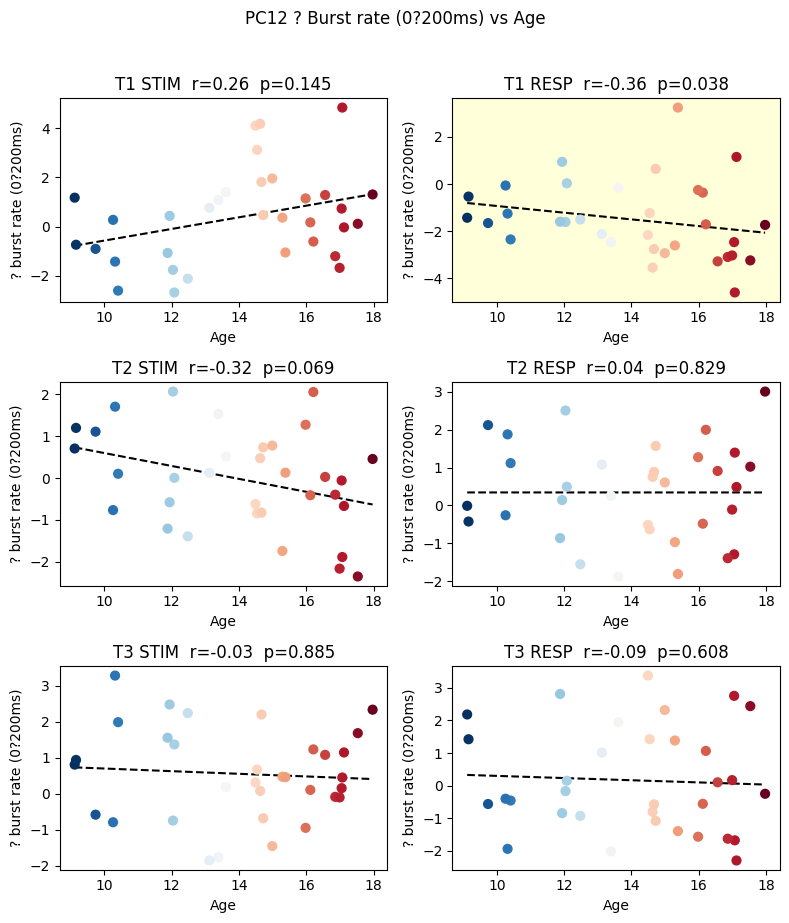

In [ ]:
from scipy.stats import spearmanr

all_subject_ids_ordered = low_subject_ids + high_subject_ids
ages_ordered = np.array([age_lookup[s] for s in all_subject_ids_ordered])

time_mask_stim = (stim_time_plt >= 0) & (stim_time_plt <= 0.15)
time_mask_resp = (resp_time_plt >= 0) & (resp_time_plt <= 0.15)

fig, axes = plt.subplots(n_q, 2, figsize=(8, n_q * 3))
fig.suptitle(f'PC{pc+1} ? Burst rate (0?200ms) vs Age', y=1.02)

for q in range(n_q):
    for ax_plt, epoch, time_mask, time_plt in [
        (axes[q, 0], 'STIM', time_mask_stim, stim_time_plt),
        (axes[q, 1], 'RESP', time_mask_resp, resp_time_plt)
    ]:
        burst_rates = []
        for age_label in ['low', 'high']:
            data = np.array(q_rates_smoothed[age_label][q][epoch]['SHORT'])
            if len(data) == 0:
                continue
            # mean burst rate over 0-200ms per subject
            mean_rate = np.mean(data[:, time_mask], axis=1)
            burst_rates.append(mean_rate)

        burst_rates = np.concatenate(burst_rates)
        n_subj      = len(burst_rates)

        r, p = spearmanr(ages_ordered[:n_subj], burst_rates)

        ax_plt.scatter(ages_ordered[:n_subj], burst_rates,
                       c=ages_ordered[:n_subj], cmap='RdBu_r', s=40, zorder=3)
        # regression line
        m, b  = np.polyfit(ages_ordered[:n_subj], burst_rates, 1)
        x_fit = np.linspace(ages_ordered[:n_subj].min(), ages_ordered[:n_subj].max(), 100)
        ax_plt.plot(x_fit, m * x_fit + b, 'k--', lw=1.5)

        ax_plt.set_title(f'T{q+1} {epoch}  r={r:.2f}  p={p:.3f}')
        ax_plt.set_xlabel('Age')
        ax_plt.set_ylabel('? burst rate (0?200ms)')
        if p < 0.05:
            ax_plt.set_facecolor((1, 1, 0.85))  # yellow highlight if significant

plt.tight_layout()
plt.show()

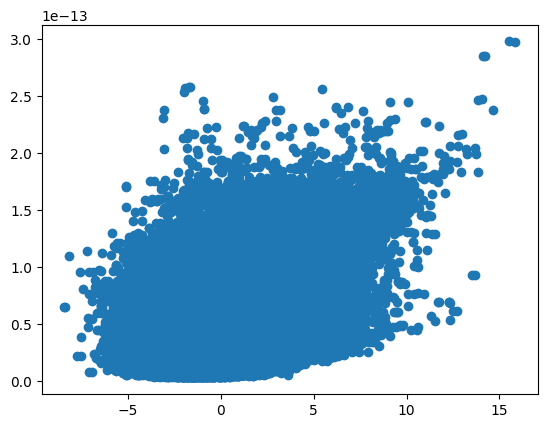

In [ ]:
plt.scatter(pc_scores[:,7], all_bursts['peak_amp_base'])

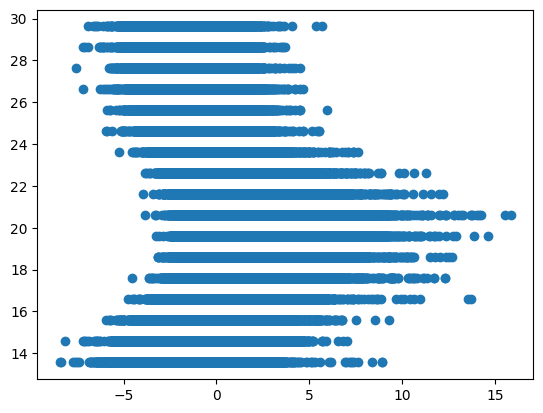

In [ ]:
plt.scatter(pc_scores[:,7], all_bursts['peak_freq'])

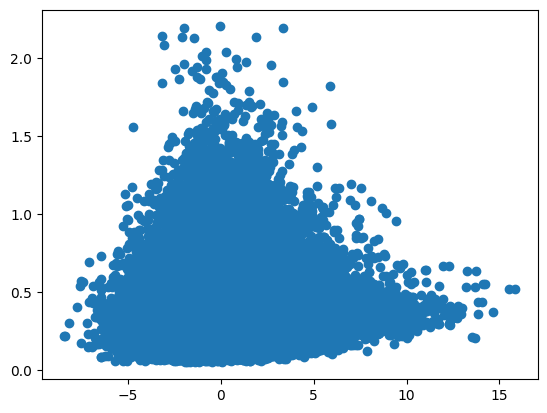

In [ ]:
plt.scatter(pc_scores[:,7], all_bursts['fwhm_time'])

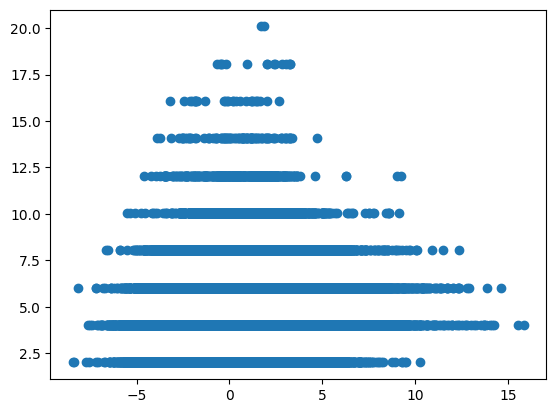

In [ ]:
plt.scatter(pc_scores[:,7], all_bursts['fwhm_freq'])

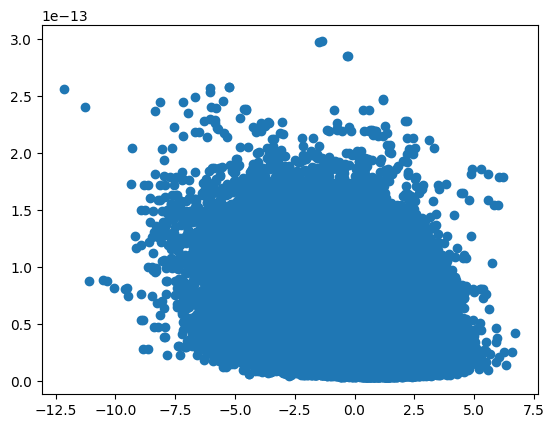

In [ ]:
plt.scatter(pc_scores[:,9], all_bursts['peak_amp_base'])

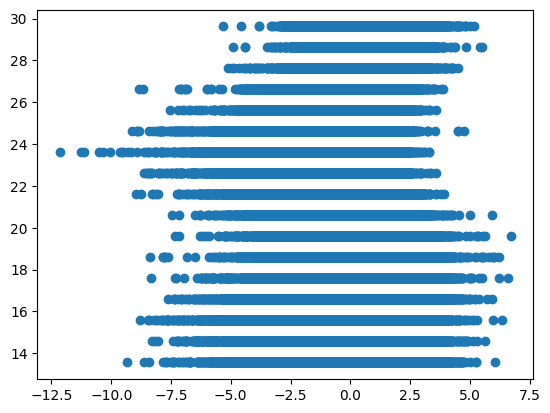

In [ ]:
plt.scatter(pc_scores[:,9], all_bursts['peak_freq'])

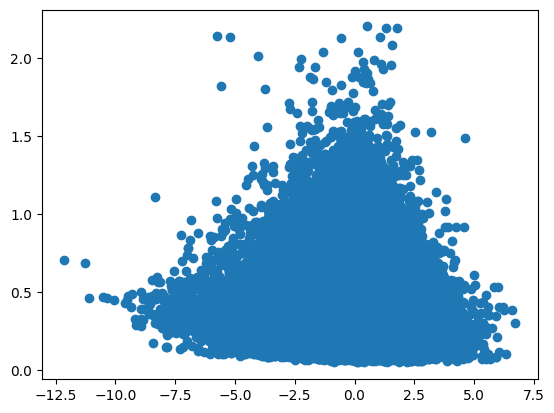

In [ ]:
plt.scatter(pc_scores[:,9], all_bursts['fwhm_time'])

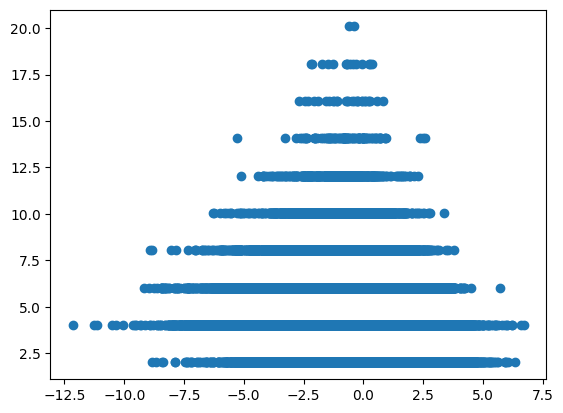

In [ ]:
plt.scatter(pc_scores[:,9], all_bursts['fwhm_freq'])

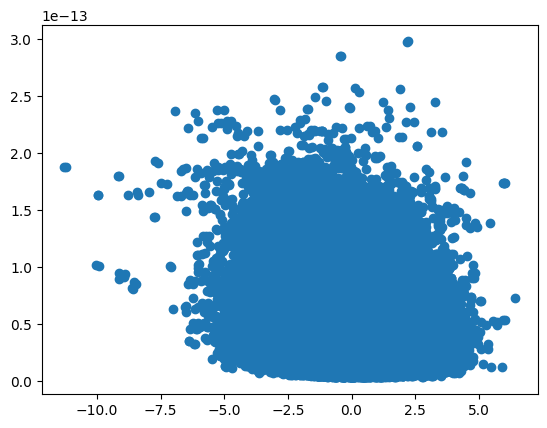

In [ ]:
plt.scatter(pc_scores[:,11], all_bursts['peak_amp_base'])

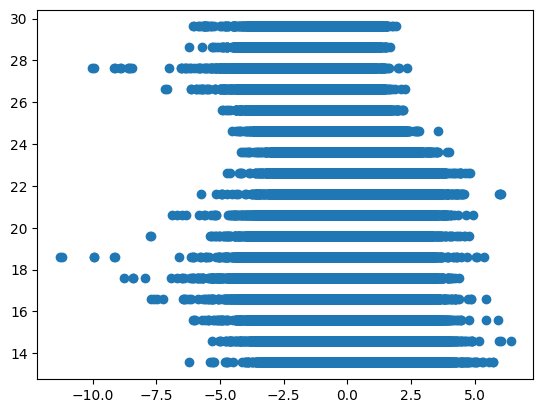

In [ ]:
plt.scatter(pc_scores[:,11], all_bursts['peak_freq'])

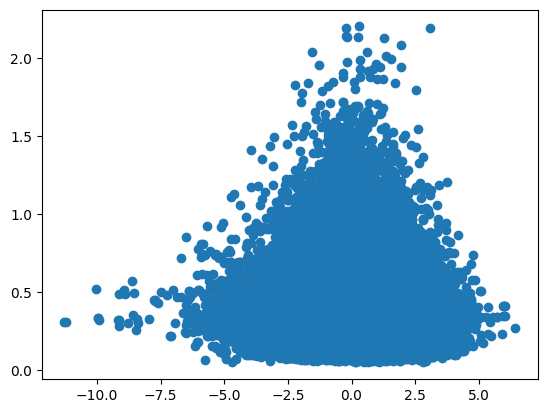

In [ ]:
plt.scatter(pc_scores[:,11], all_bursts['fwhm_time'])

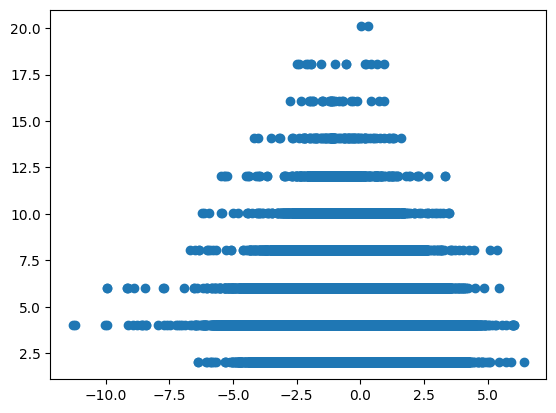

In [ ]:
plt.scatter(pc_scores[:,11], all_bursts['fwhm_freq'])

Text(0, 0.5, 'PC10 score')

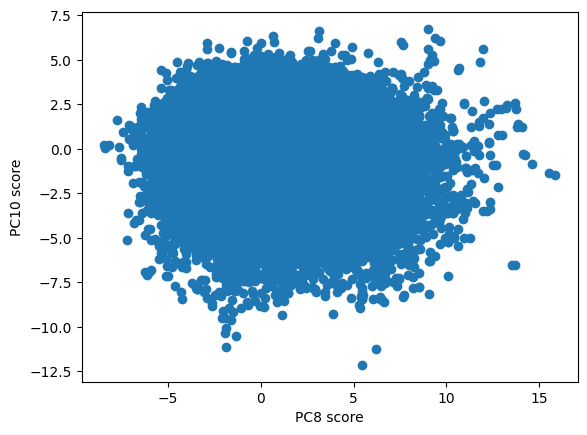

In [ ]:
plt.scatter(pc_scores[:,7],pc_scores[:,9])
plt.xlabel('PC8 score')
plt.ylabel('PC10 score')

Text(0, 0.5, 'PC12 score')

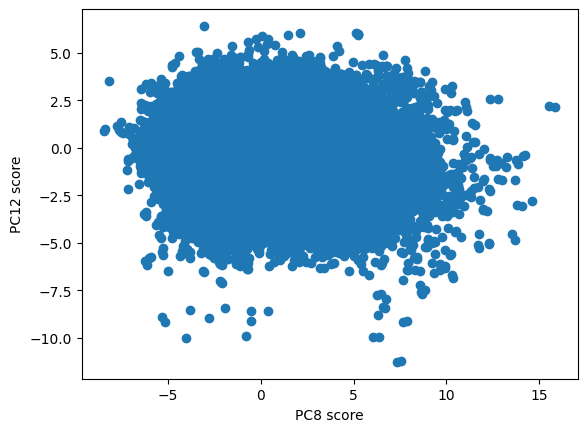

In [ ]:
plt.scatter(pc_scores[:,7],pc_scores[:,11])
plt.xlabel('PC8 score')
plt.ylabel('PC12 score')

Text(0, 0.5, 'PC12 score')

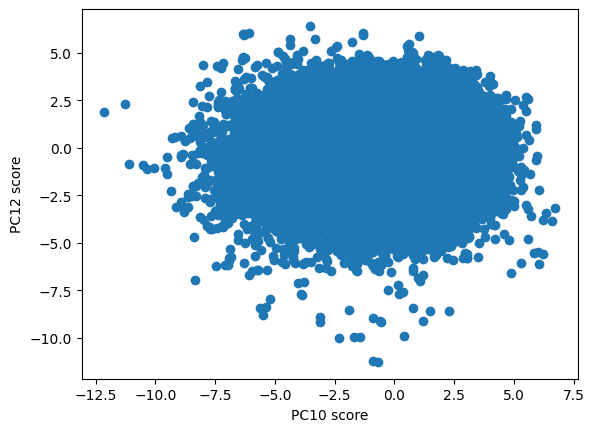

In [ ]:
plt.scatter(pc_scores[:,9],pc_scores[:,11])
plt.xlabel('PC10 score')
plt.ylabel('PC12 score')